In [1]:
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
from datetime import datetime

# Set GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
jax.config.update('jax_platform_name', 'gpu')


In [2]:
!nvidia-smi


Fri Jun 13 13:42:59 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti      Off| 00000000:1A:00.0 Off |                  N/A |
| 16%   26C    P8                1W / 250W|     18MiB / 11264MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

/home/guoqi/.conda/envs/MAPLE/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


|   4  Tesla V100-PCIE-32GB            Off| 00000000:21:00.0 Off |                    0 |
| N/A   33C    P0               36W / 250W|  32316MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+----------------------+
|   5  Tesla V100-PCIE-32GB            Off| 00000000:22:00.0 Off |                    0 |
| N/A   70C    P0              253W / 250W|  28586MiB / 32768MiB |    100%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+----------------------+
|   6  NVIDIA GeForce RTX 2080 Ti      Off| 00000000:23:00.0 Off |                  N/A |
| 16%   29C    P8               17W / 250W|      1MiB / 11264MiB |      0%      Default |
|                                         |                      |                  N/A |
+---------

In [3]:
from config_generator import load_config, generate_default_config
from power_spectrum import setup_power_spectrum
from data_loader import setup_data_loaders, load_observation_data, load_simulation_data
from muse_problem import create_muse_problem
from optimization import MuseOptimizer, CovarianceEstimator, run_full_analysis

In [4]:
try:
    config = load_config("p3d_config.yaml")
    print("Loaded existing configuration")
except FileNotFoundError:
    print("Creating default configuration...")
    config = generate_default_config()
    
print(f"Running analysis with:")
print(f"  Box size: {config['simulation']['box_size']} Mpc/h")
print(f"  Grid size: {config['simulation']['n_cells']}^3")
print(f"  Redshift: {config['simulation']['redshift']}")
print(f"  Max steps: {config['optimization']['max_steps']}")


Creating default configuration...
Running analysis with:
  Box size: 150 Mpc/h
  Grid size: 150^3
  Redshift: 2.0
  Max steps: 200


In [5]:
# Setup power spectrum
print("\nSetting up power spectrum...")
power_data = setup_power_spectrum(config)



Setting up power spectrum...


2025-06-13 13:43:03.594317: W external/xla/xla/service/gpu/nvptx_compiler.cc:718] The NVIDIA driver's CUDA version is 12.1 which is older than the ptxas CUDA version (12.8.93). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Loaded model array shape: (66, 3), kmax: 3.2255218029022217


In [6]:
print("Loading data...")
data_loaders = setup_data_loaders(config)
obs_data = load_observation_data(config)
sim_data = load_simulation_data(config)


Loading data...
Loaded naa: (9591600,)
Loaded kernel: (1, 1198950, 8)
Loaded skewers_skn: (1198950,)
Loaded skewers_dla: (1198950,)
Loaded skewers_fin: (1198950, 3)
Loaded simulation data: (154, 154, 154)
Loaded naa: (9591600,)
Loaded kernel: (1, 1198950, 8)
Loaded skewers_skn: (1198950,)
Loaded skewers_dla: (1198950,)
Loaded skewers_fin: (1198950, 3)
Loaded simulation data: (154, 154, 154)


In [7]:
# Create MUSE problem
print("Creating MUSE problem...")
problem = create_muse_problem(power_data, data_loaders, config)
problem.set_x(data_loaders['lya']['map_lya_sim'])

key = jax.random.PRNGKey(100)
x_data = problem.sample_x_z(key, problem.tf_cut_flat)[0]
# Setup initial conditions
start_point = problem.get_starting_point(perturbation_scale=0.01)

Creating MUSE problem...


/home/guoqi/.conda/envs/MAPLE/lib/python3.9/site-packages/jax/_src/api_util.py:233: SyntaxWarning: Jitted function has invalid argnames {'self'} in static_argnames. Function does not take these args.This warning will be replaced by an error after 2022-08-20 at the earliest.
  warnings.warn(f"Jitted function has invalid argnames {invalid_argnames} "


In [8]:
# Initialize random key
rng = jax.random.PRNGKey(config['random_seed'])

# Run complete analysis
print(f"\nStarting MUSE analysis at {datetime.now()}")
print("="*50)


Starting MUSE analysis at 2025-06-13 13:43:17.408514


Running MUSE optimization...
Starting MUSE optimization...
Parameters: maxsteps=200, nsims=10
Optimization step: 1, learning rate: 0.700000
Optimization step: 2, learning rate: 0.700000
Optimization step: 3, learning rate: 0.700000
Optimization step: 4, learning rate: 0.665000
Optimization step: 5, learning rate: 0.665000
Optimization step: 6, learning rate: 0.665000


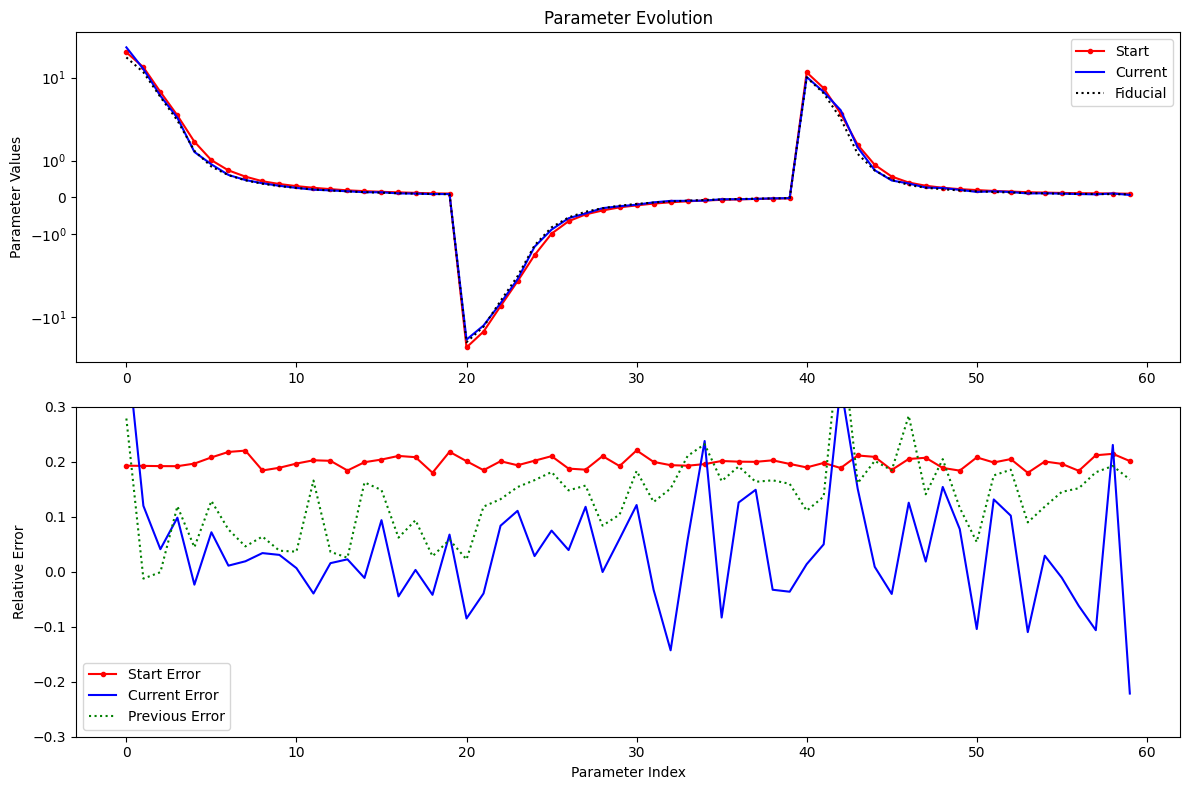

Optimization step: 7, learning rate: 0.631750
Optimization step: 8, learning rate: 0.631750
Optimization step: 9, learning rate: 0.631750
Optimization step: 10, learning rate: 0.600162
Optimization step: 11, learning rate: 0.600162
Optimization step: 12, learning rate: 0.600162


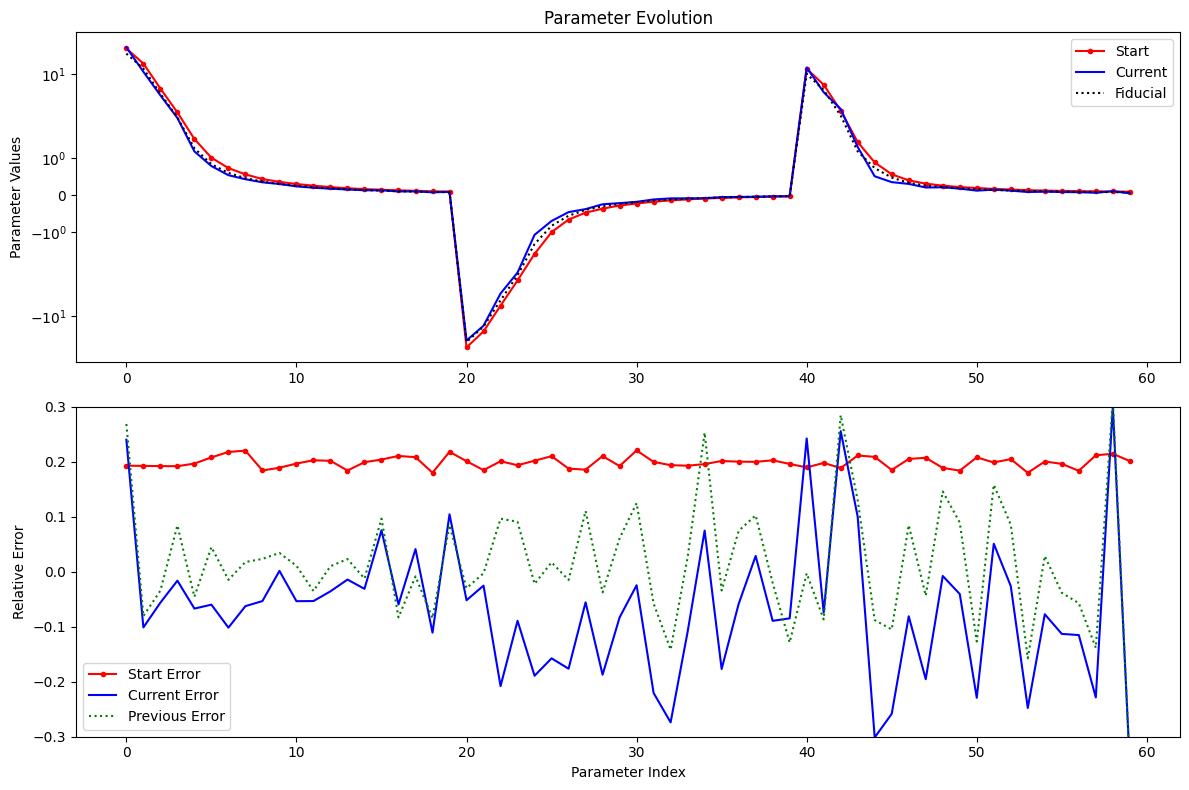

Optimization step: 13, learning rate: 0.570154
Optimization step: 14, learning rate: 0.570154
Optimization step: 15, learning rate: 0.570154
Optimization step: 16, learning rate: 0.541647
Optimization step: 17, learning rate: 0.541647
Optimization step: 18, learning rate: 0.541647


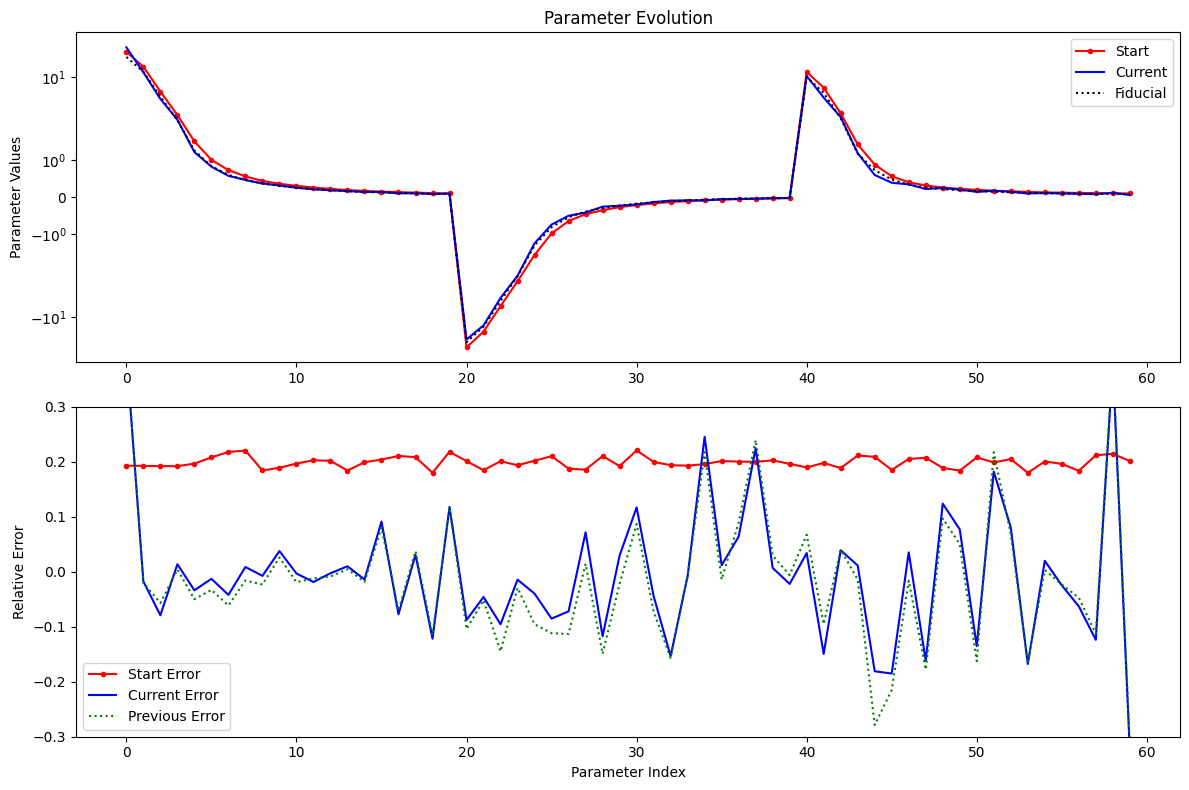

Optimization step: 19, learning rate: 0.514564
Optimization step: 20, learning rate: 0.514564
Optimization step: 21, learning rate: 0.514564
Optimization step: 22, learning rate: 0.488836
Optimization step: 23, learning rate: 0.488836
Optimization step: 24, learning rate: 0.488836


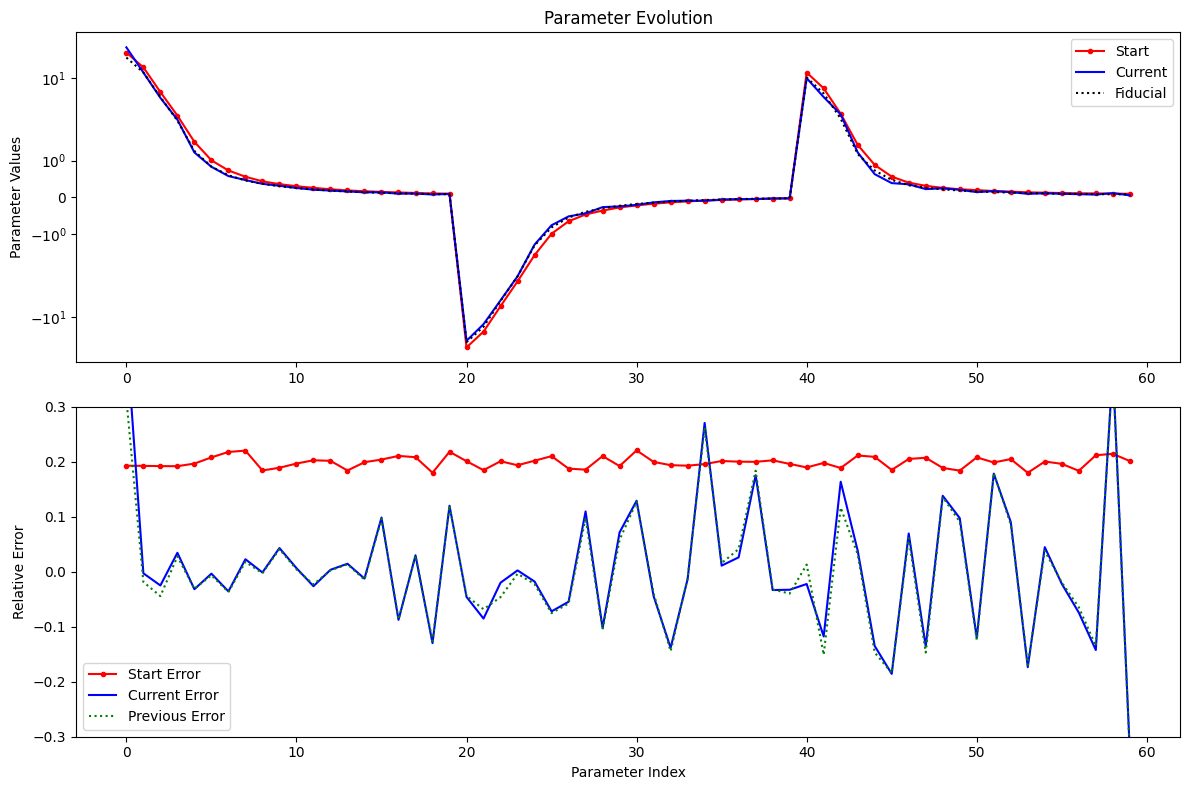

Optimization step: 25, learning rate: 0.464394
Optimization step: 26, learning rate: 0.464394
Optimization step: 27, learning rate: 0.464394
Optimization step: 28, learning rate: 0.441175
Optimization step: 29, learning rate: 0.441175
Optimization step: 30, learning rate: 0.441175


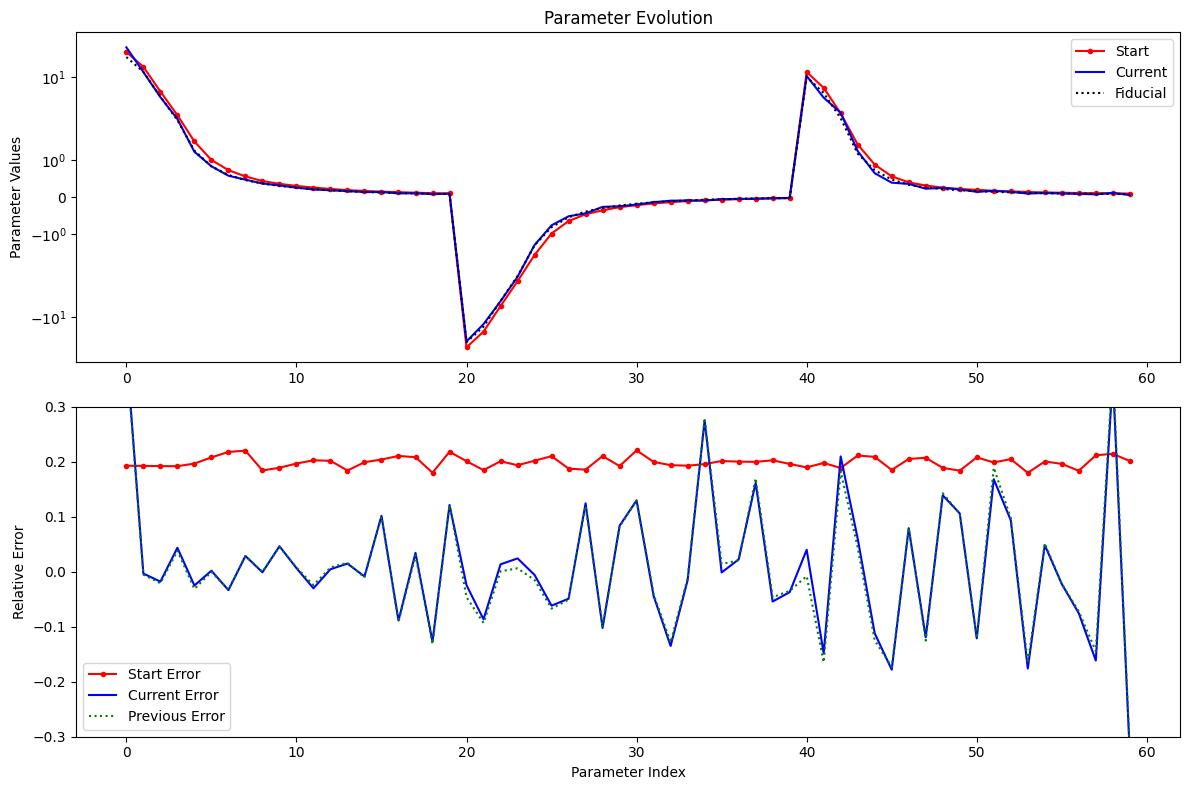

Optimization step: 31, learning rate: 0.419116
Optimization step: 32, learning rate: 0.419116
Optimization step: 33, learning rate: 0.419116
Optimization step: 34, learning rate: 0.398160
Optimization step: 35, learning rate: 0.398160
Optimization step: 36, learning rate: 0.398160


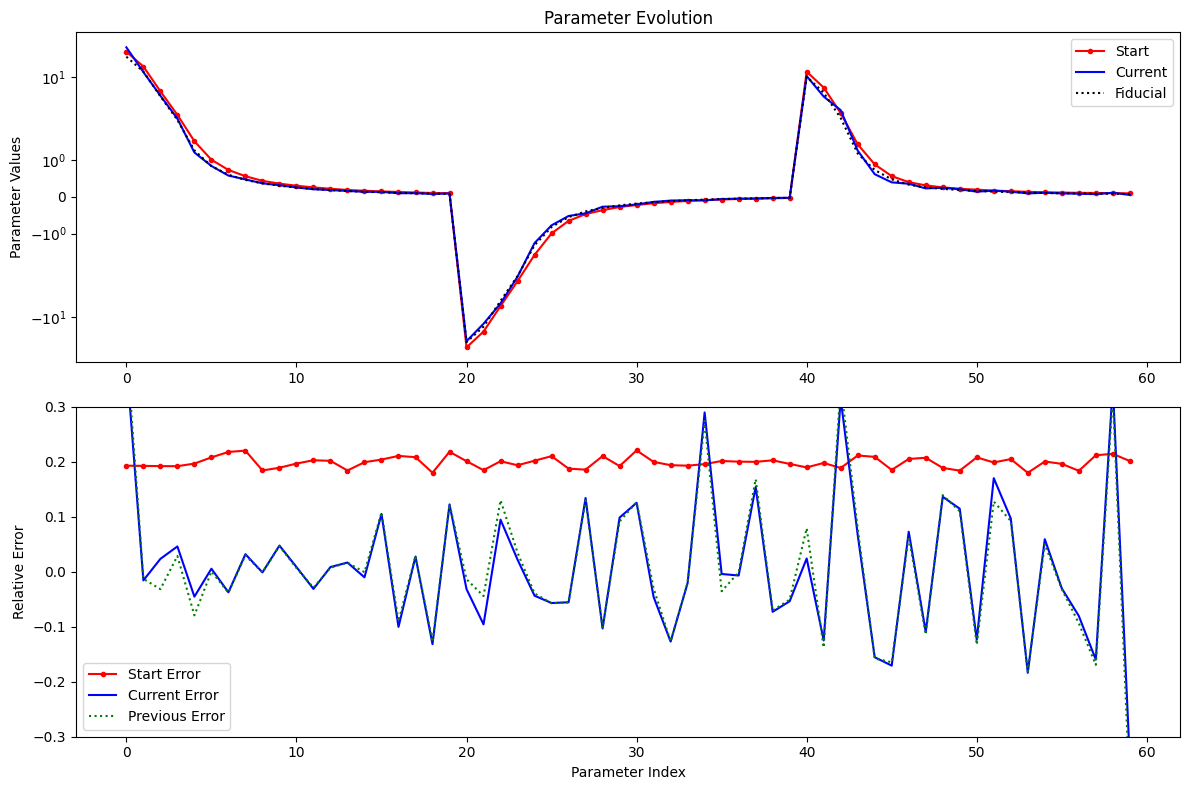

Optimization step: 37, learning rate: 0.378252
Optimization step: 38, learning rate: 0.378252
Optimization step: 39, learning rate: 0.378252
Optimization step: 40, learning rate: 0.359339
Optimization step: 41, learning rate: 0.359339
Optimization step: 42, learning rate: 0.359339


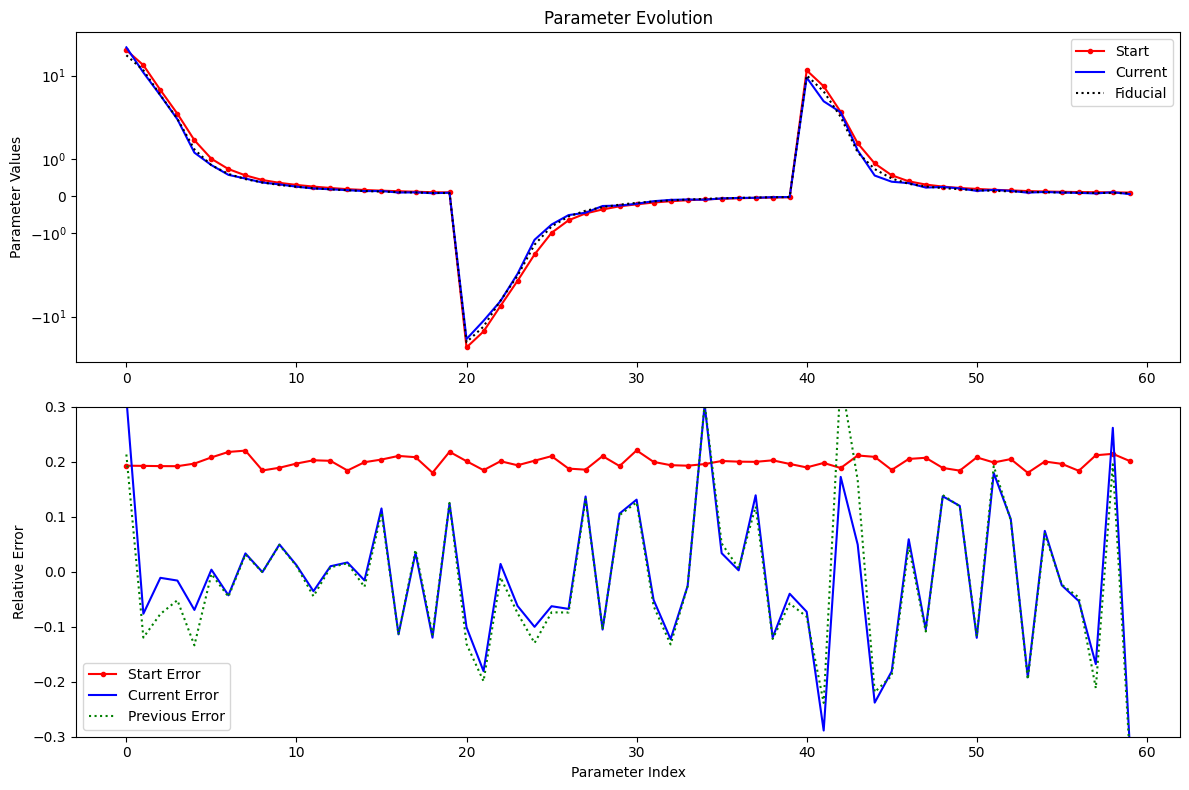

Optimization step: 43, learning rate: 0.341372
Optimization step: 44, learning rate: 0.341372
Optimization step: 45, learning rate: 0.341372
Optimization step: 46, learning rate: 0.324304
Optimization step: 47, learning rate: 0.324304
Optimization step: 48, learning rate: 0.324304


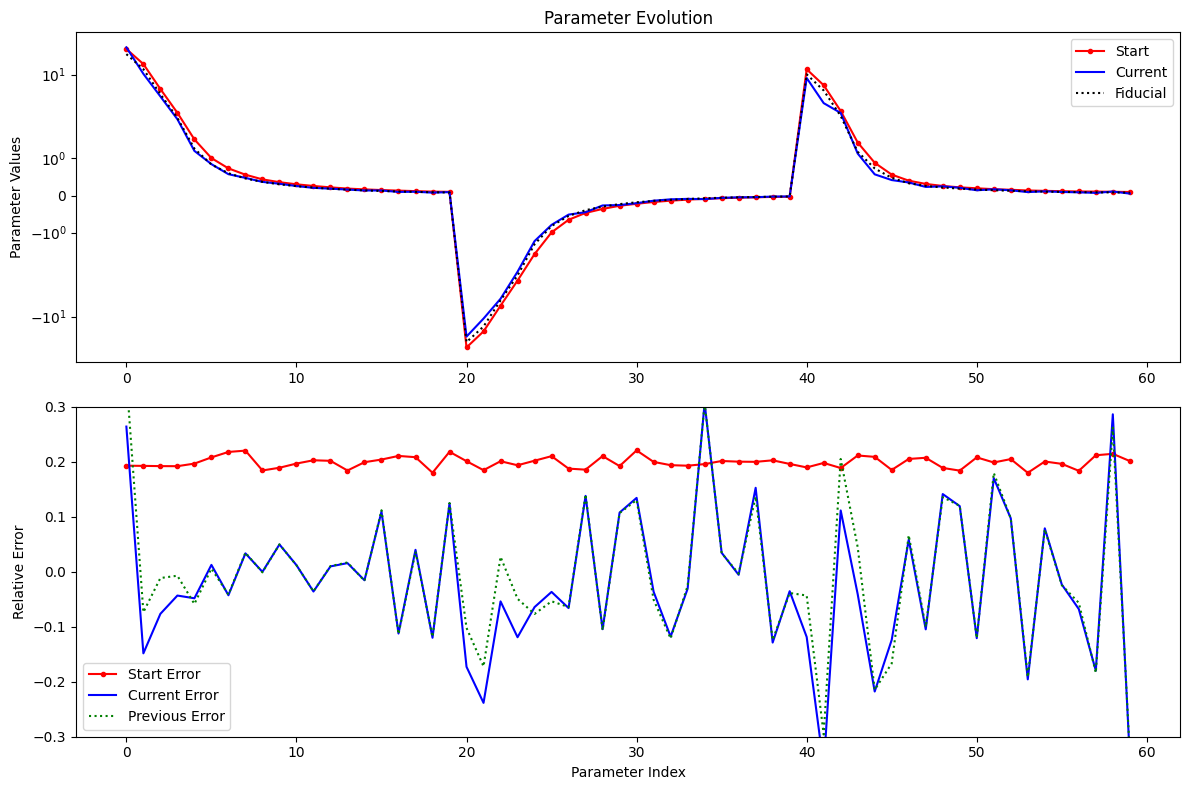

Optimization step: 49, learning rate: 0.308089
Optimization step: 50, learning rate: 0.308089
Optimization step: 51, learning rate: 0.308089
Optimization step: 52, learning rate: 0.292684
Optimization step: 53, learning rate: 0.292684
Optimization step: 54, learning rate: 0.292684


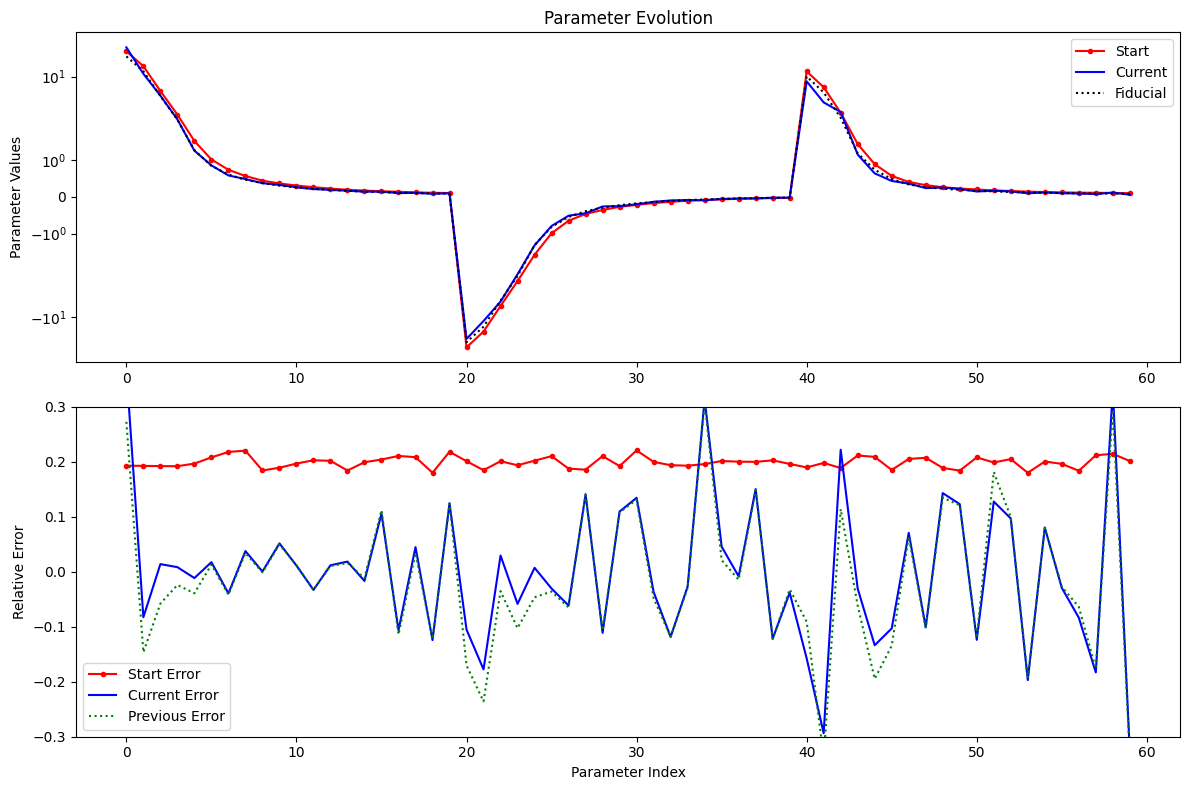

Optimization step: 55, learning rate: 0.278050
Optimization step: 56, learning rate: 0.278050
Optimization step: 57, learning rate: 0.278050
Optimization step: 58, learning rate: 0.264148
Optimization step: 59, learning rate: 0.264148
Optimization step: 60, learning rate: 0.264148


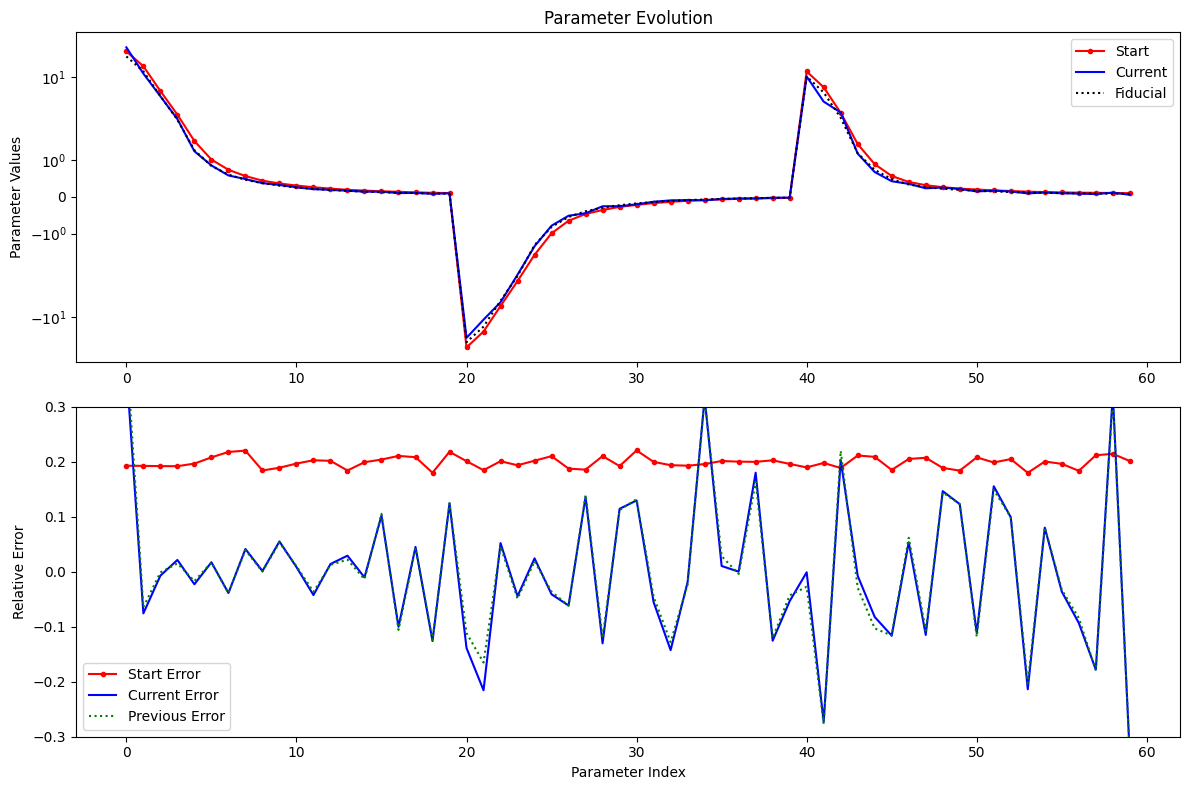

Optimization step: 61, learning rate: 0.250940
Optimization step: 62, learning rate: 0.250940
Optimization step: 63, learning rate: 0.250940
Optimization step: 64, learning rate: 0.238393
Optimization step: 65, learning rate: 0.238393
Optimization step: 66, learning rate: 0.238393


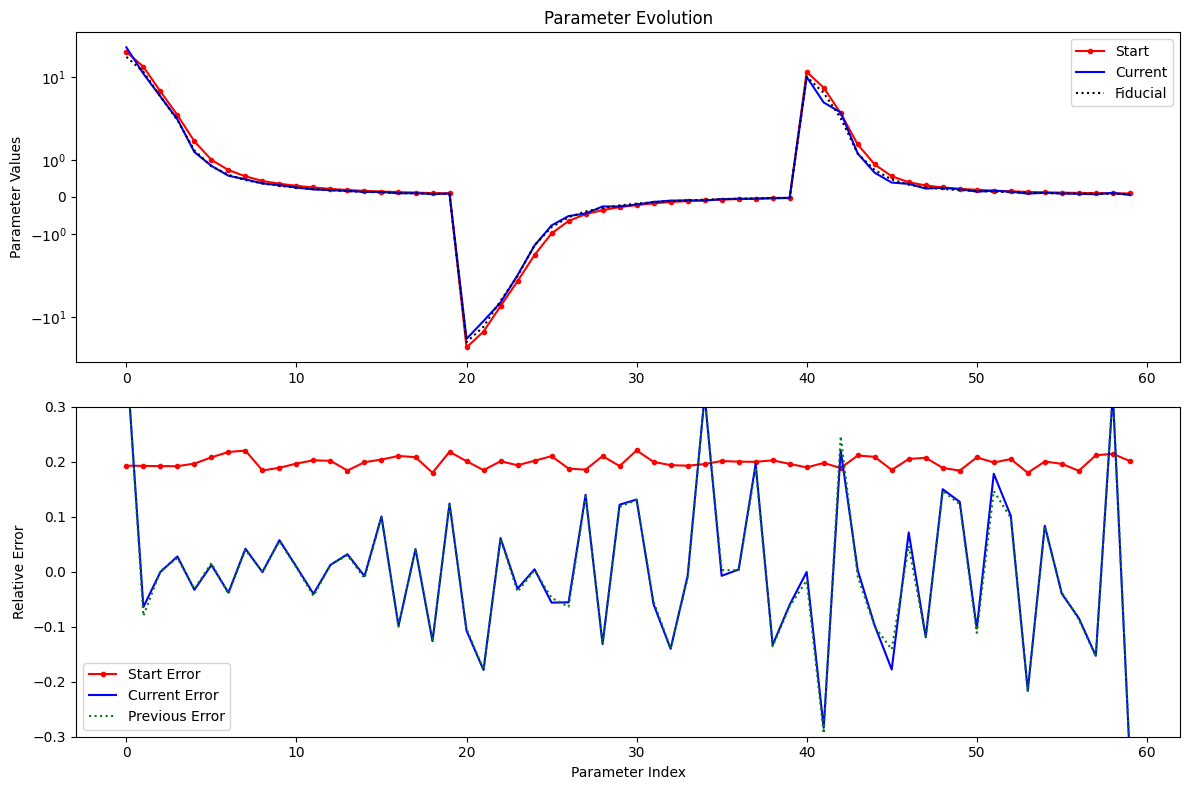

Optimization step: 67, learning rate: 0.226473
Optimization step: 68, learning rate: 0.226473
Optimization step: 69, learning rate: 0.226473
Optimization step: 70, learning rate: 0.215150
Optimization step: 71, learning rate: 0.215150
Optimization step: 72, learning rate: 0.215150


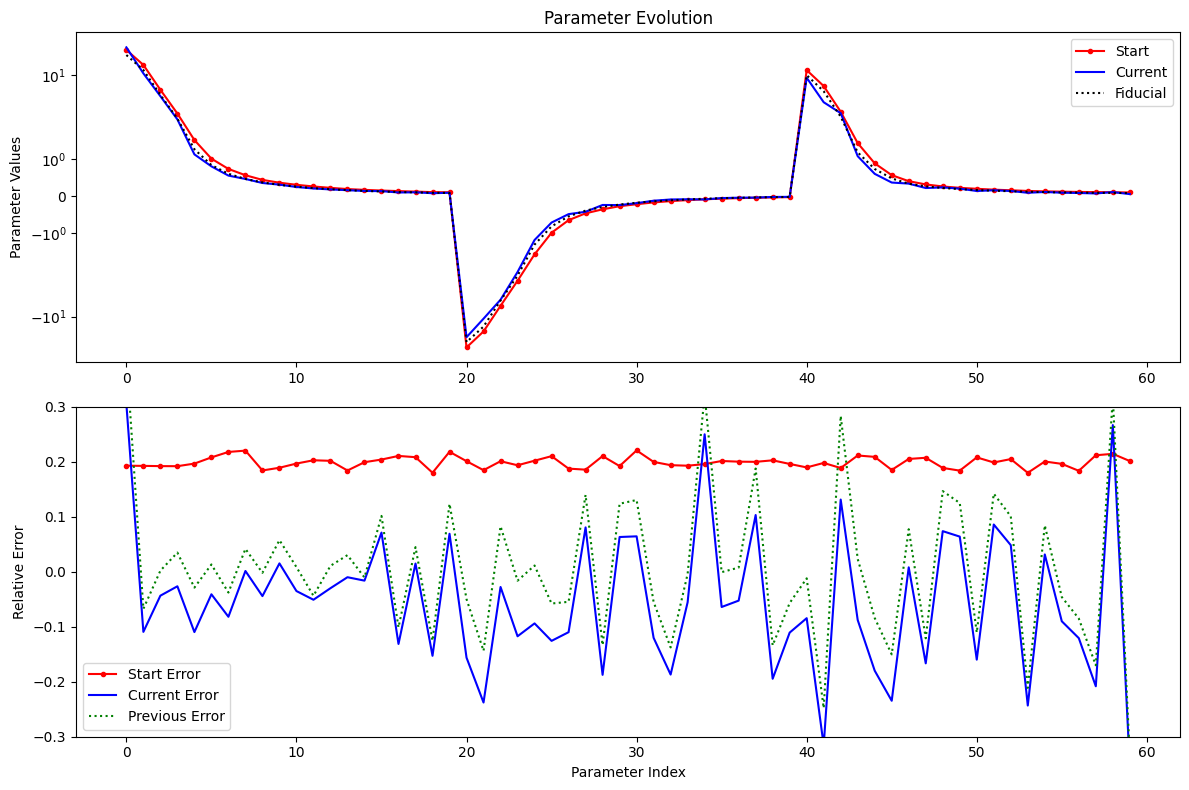

Optimization step: 73, learning rate: 0.204392
Optimization step: 74, learning rate: 0.204392
Optimization step: 75, learning rate: 0.204392
Optimization step: 76, learning rate: 0.194173
Optimization step: 77, learning rate: 0.194173
Optimization step: 78, learning rate: 0.194173


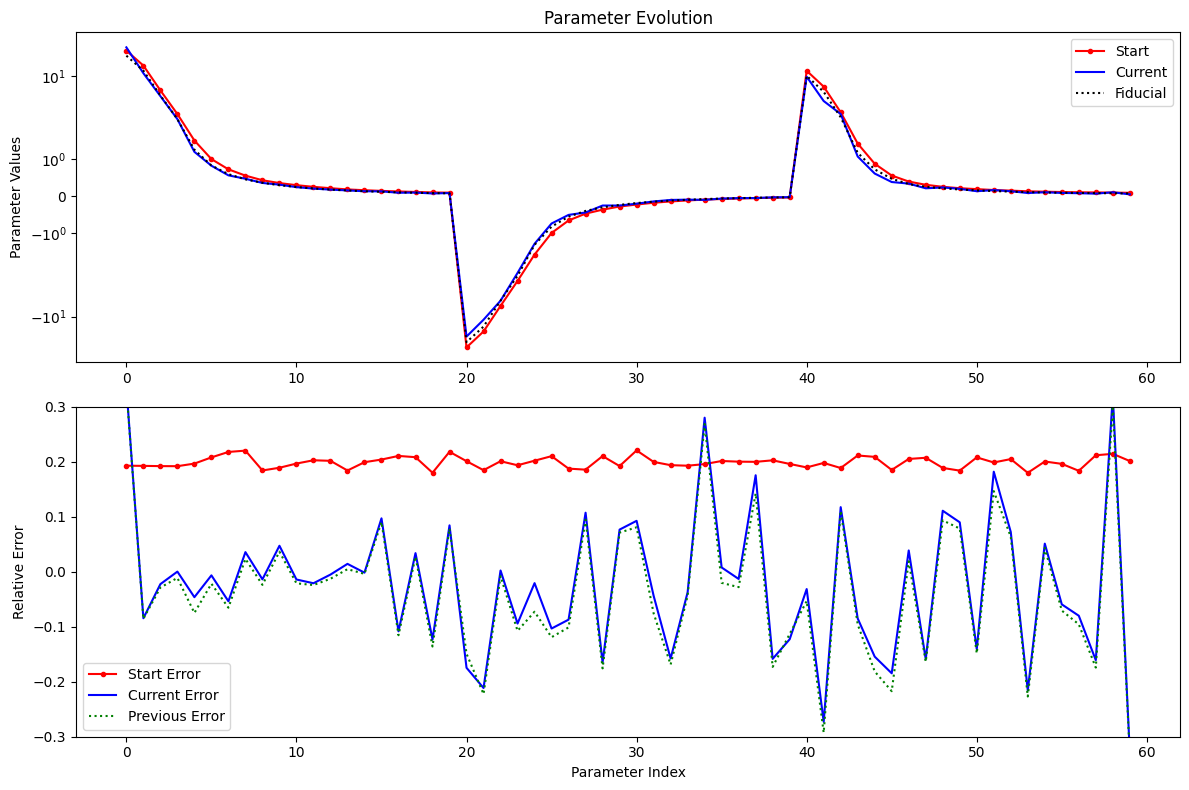

Optimization step: 79, learning rate: 0.184464
Optimization step: 80, learning rate: 0.184464
Optimization step: 81, learning rate: 0.184464
Optimization step: 82, learning rate: 0.175241
Optimization step: 83, learning rate: 0.175241
Optimization step: 84, learning rate: 0.175241


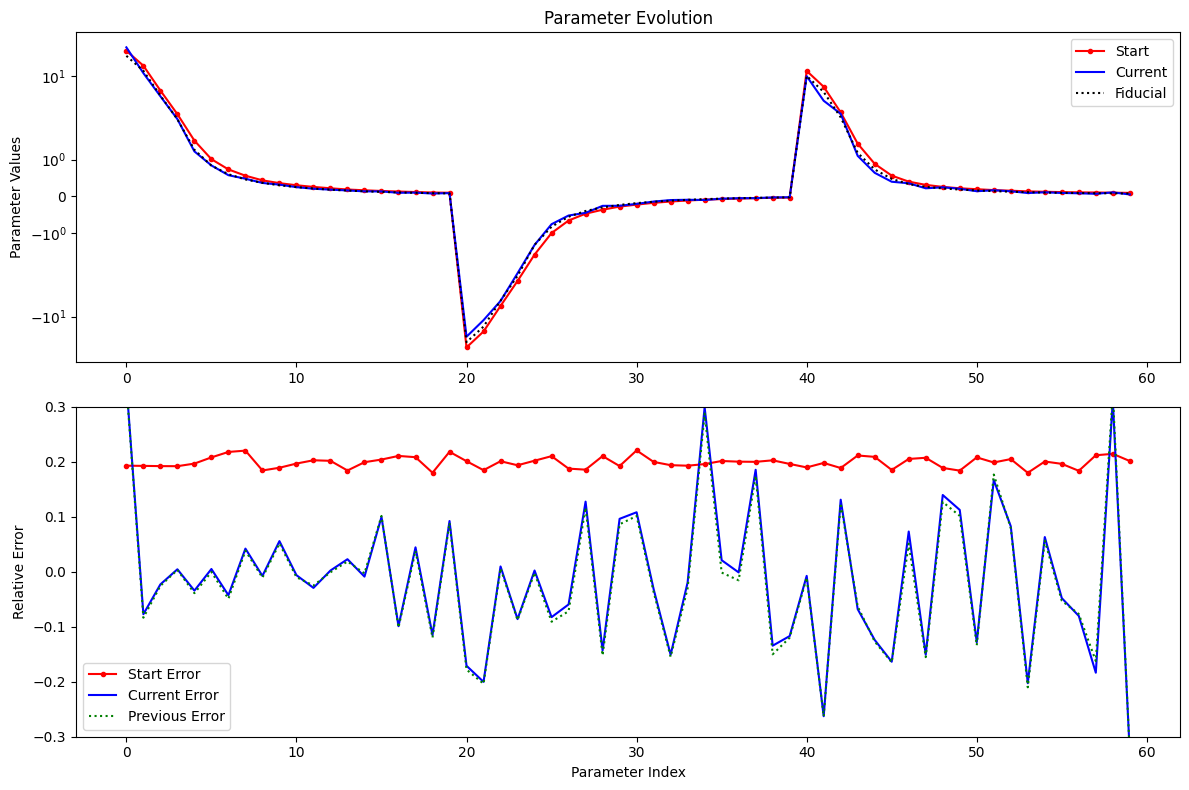

Optimization step: 85, learning rate: 0.166479
Optimization step: 86, learning rate: 0.166479
Optimization step: 87, learning rate: 0.166479
Optimization step: 88, learning rate: 0.158155
Optimization step: 89, learning rate: 0.158155
Optimization step: 90, learning rate: 0.158155


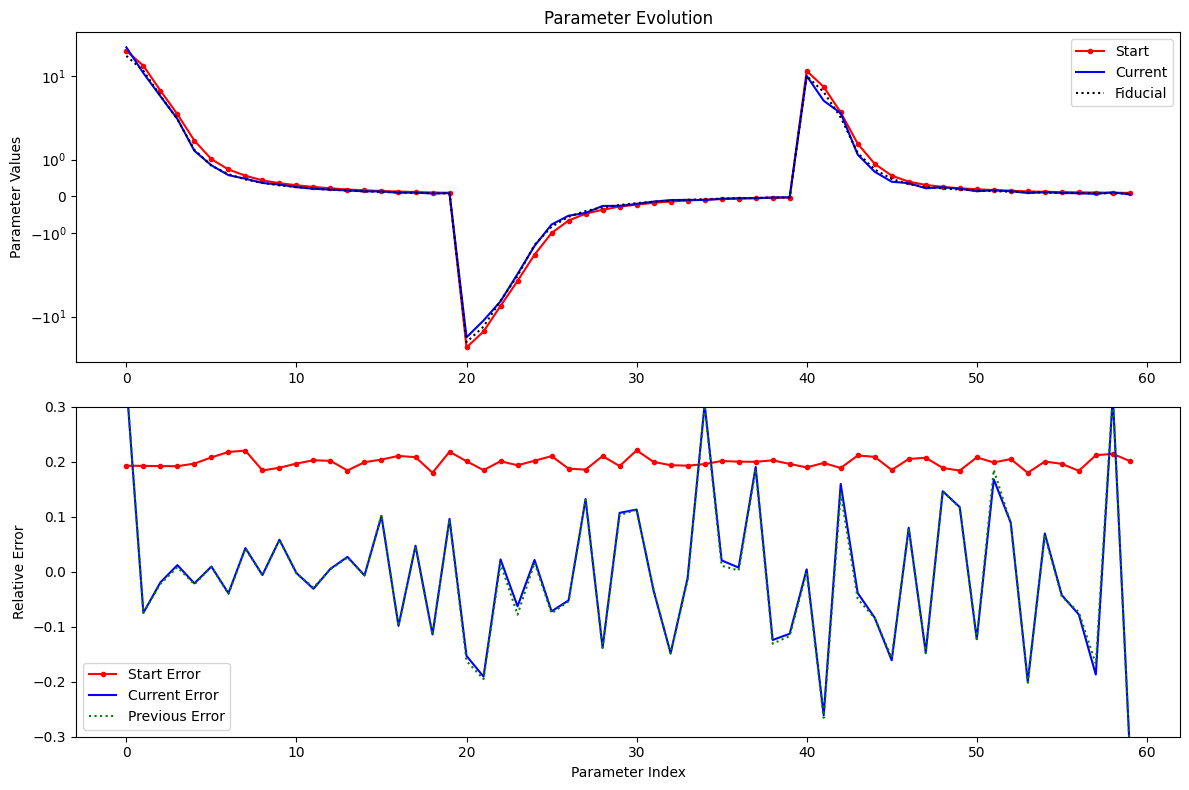

Optimization step: 91, learning rate: 0.150247
Optimization step: 92, learning rate: 0.150247
Optimization step: 93, learning rate: 0.150247
Optimization step: 94, learning rate: 0.142735
Optimization step: 95, learning rate: 0.142735
Optimization step: 96, learning rate: 0.142735


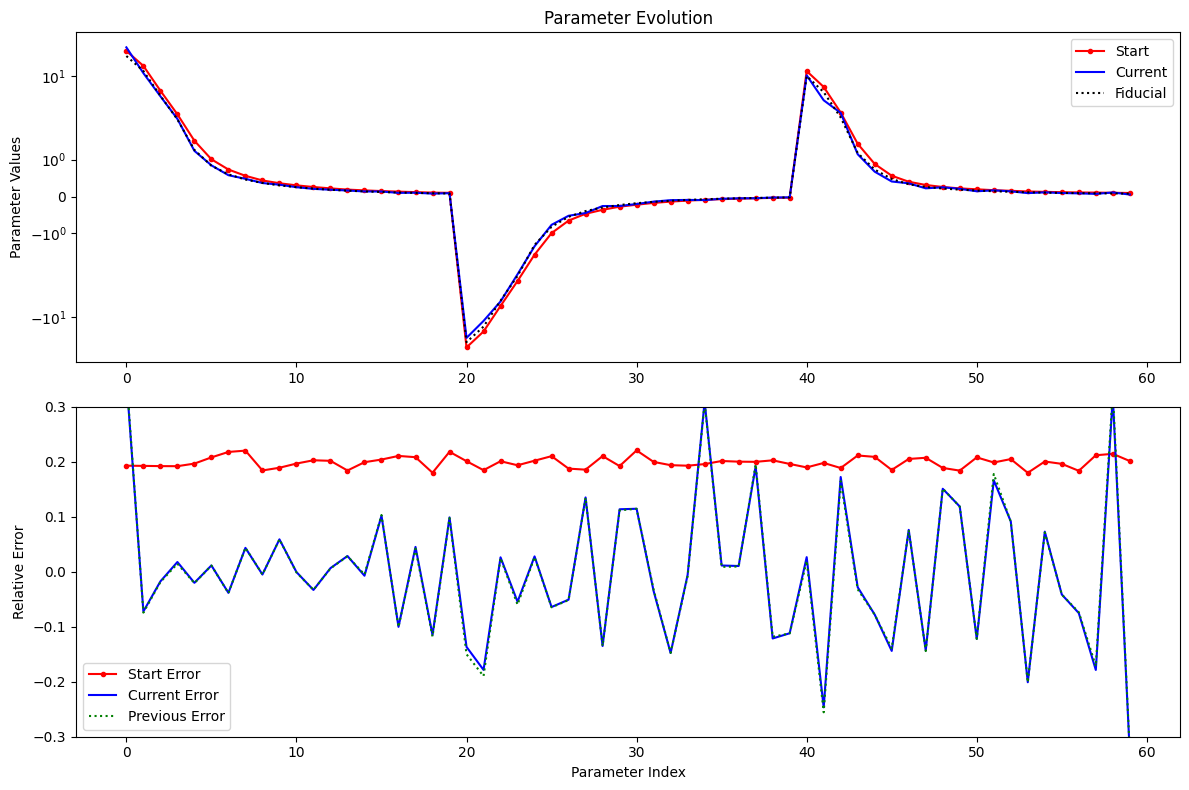

Optimization step: 97, learning rate: 0.135598
Optimization step: 98, learning rate: 0.135598
Optimization step: 99, learning rate: 0.135598
Optimization step: 100, learning rate: 0.128818
Optimization step: 101, learning rate: 0.128818
Optimization step: 102, learning rate: 0.128818


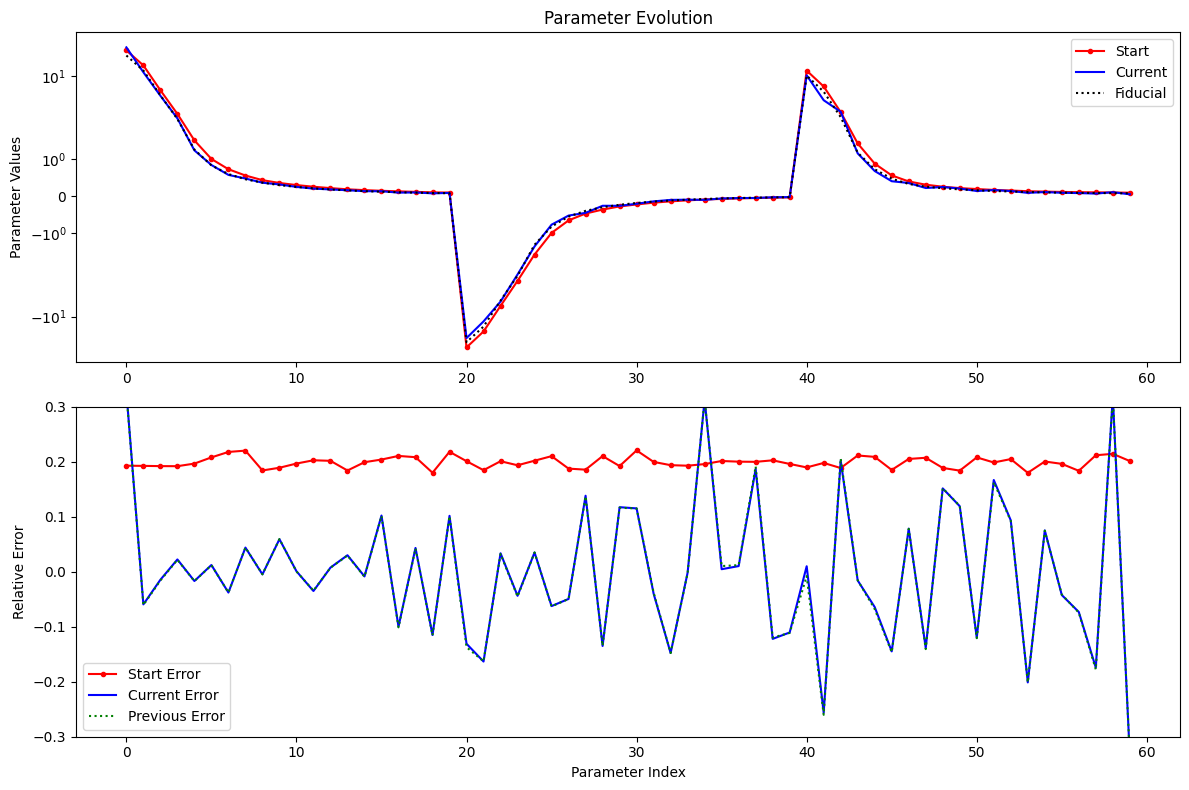

Optimization step: 103, learning rate: 0.122377
Optimization step: 104, learning rate: 0.122377
Optimization step: 105, learning rate: 0.122377
Optimization step: 106, learning rate: 0.116258
Optimization step: 107, learning rate: 0.116258
Optimization step: 108, learning rate: 0.116258


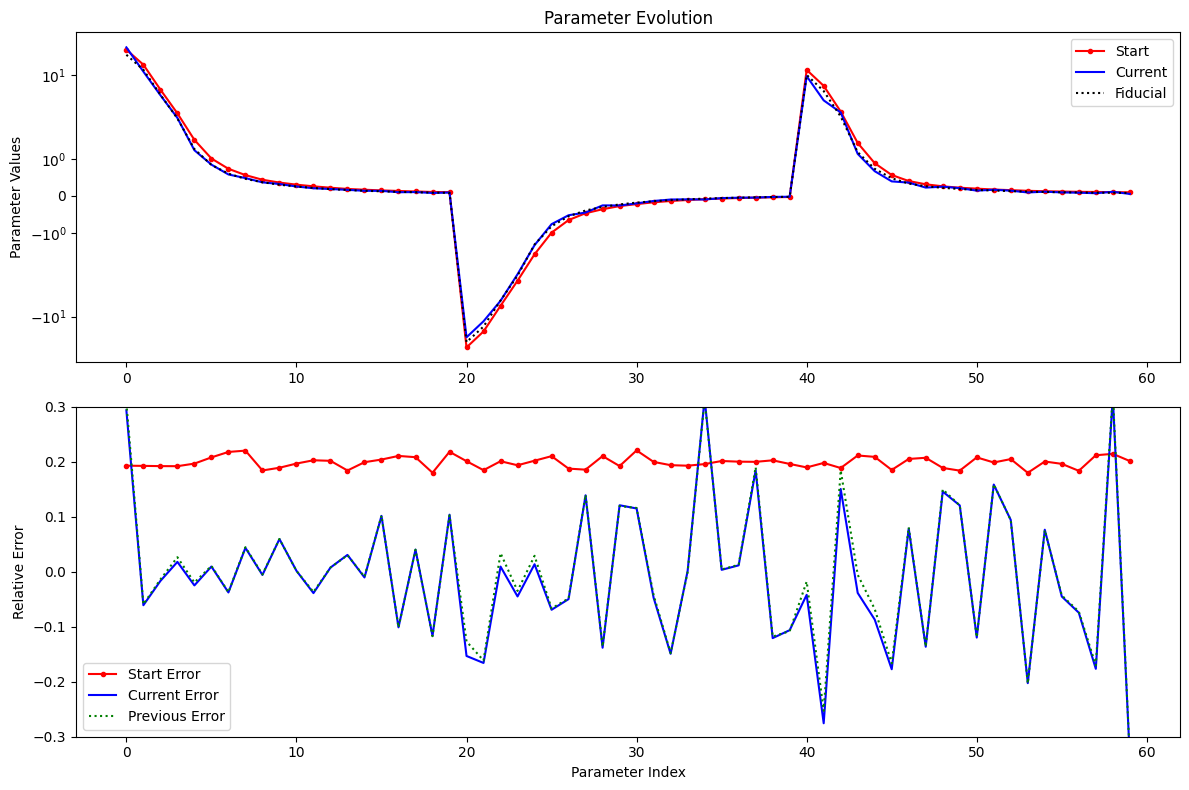

Optimization step: 109, learning rate: 0.110445
Optimization step: 110, learning rate: 0.110445
Optimization step: 111, learning rate: 0.110445
Optimization step: 112, learning rate: 0.104923
Optimization step: 113, learning rate: 0.104923
Optimization step: 114, learning rate: 0.104923


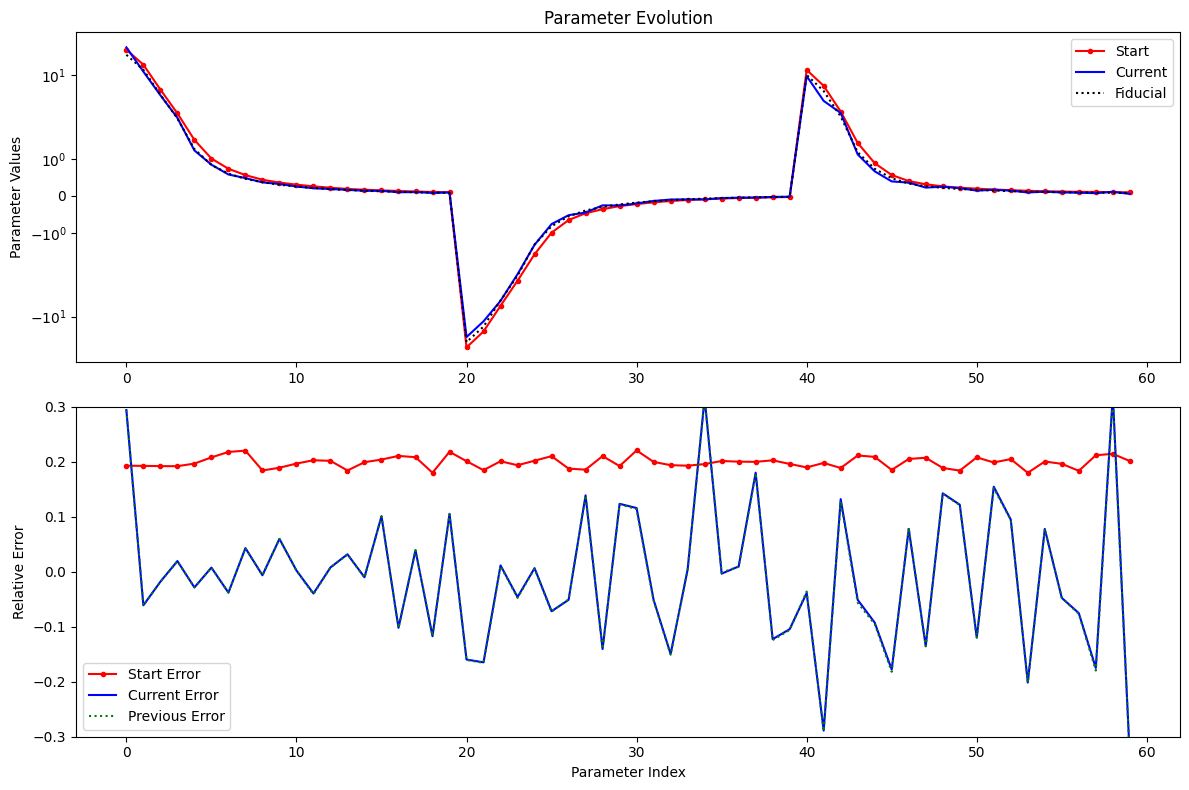

Optimization step: 115, learning rate: 0.099677
Optimization step: 116, learning rate: 0.099677
Optimization step: 117, learning rate: 0.099677
Optimization step: 118, learning rate: 0.094693
Optimization step: 119, learning rate: 0.094693
Optimization step: 120, learning rate: 0.094693


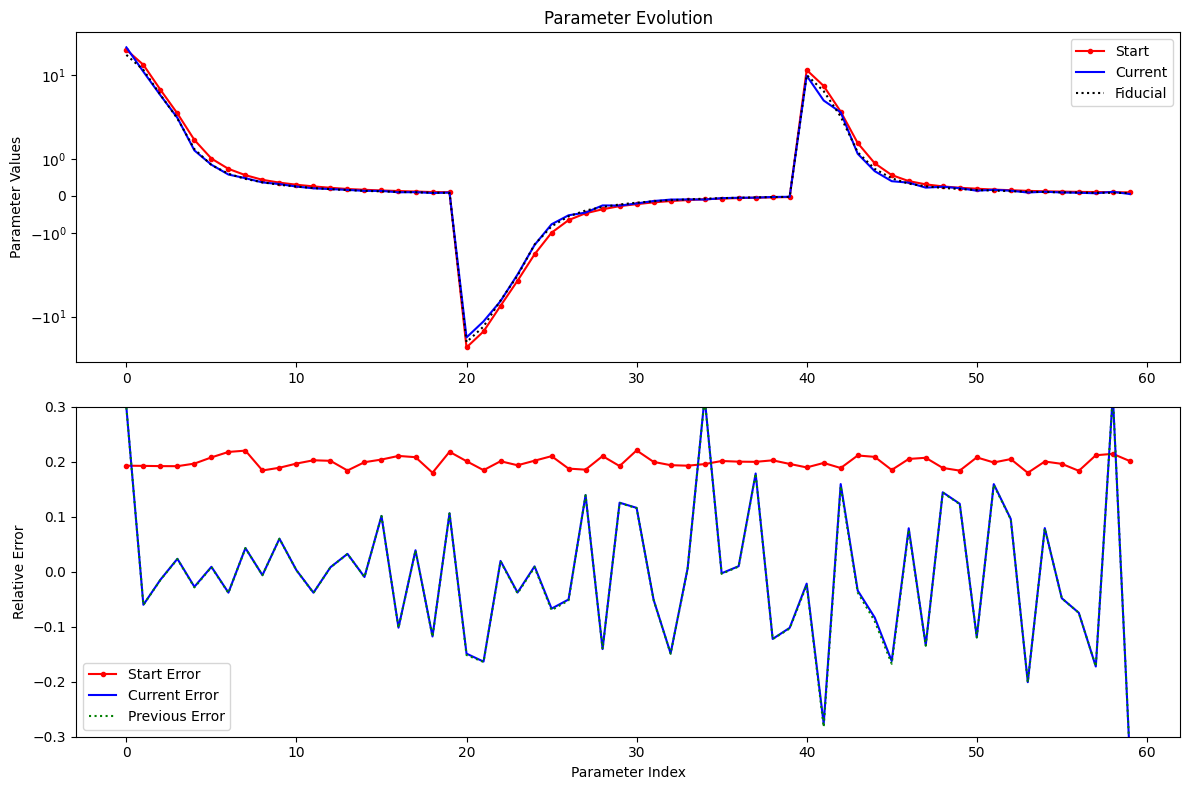

Optimization step: 121, learning rate: 0.089959
Optimization step: 122, learning rate: 0.089959
Optimization step: 123, learning rate: 0.089959
Optimization step: 124, learning rate: 0.085461
Optimization step: 125, learning rate: 0.085461
Optimization step: 126, learning rate: 0.085461


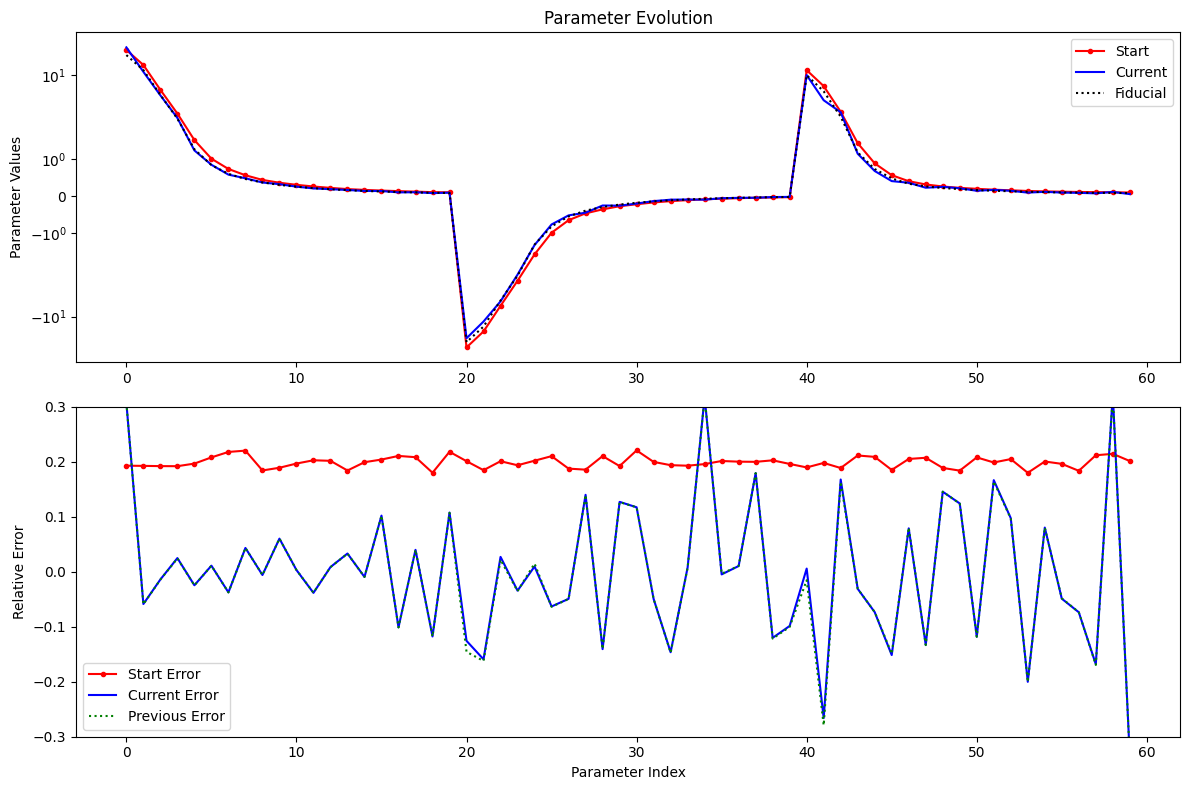

Optimization step: 127, learning rate: 0.081188
Optimization step: 128, learning rate: 0.081188
Optimization step: 129, learning rate: 0.081188
Optimization step: 130, learning rate: 0.077128
Optimization step: 131, learning rate: 0.077128
Optimization step: 132, learning rate: 0.077128


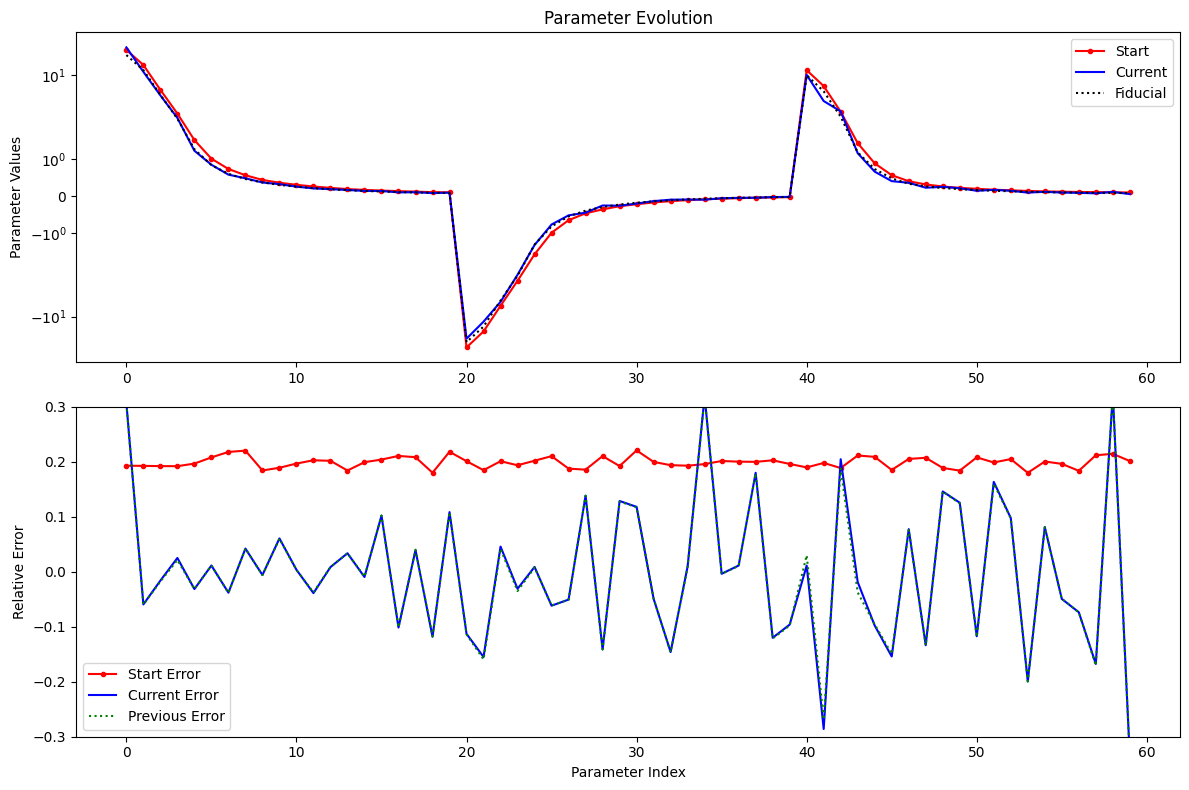

Optimization step: 133, learning rate: 0.073272
Optimization step: 134, learning rate: 0.073272
Optimization step: 135, learning rate: 0.073272
Optimization step: 136, learning rate: 0.069608
Optimization step: 137, learning rate: 0.069608
Optimization step: 138, learning rate: 0.069608


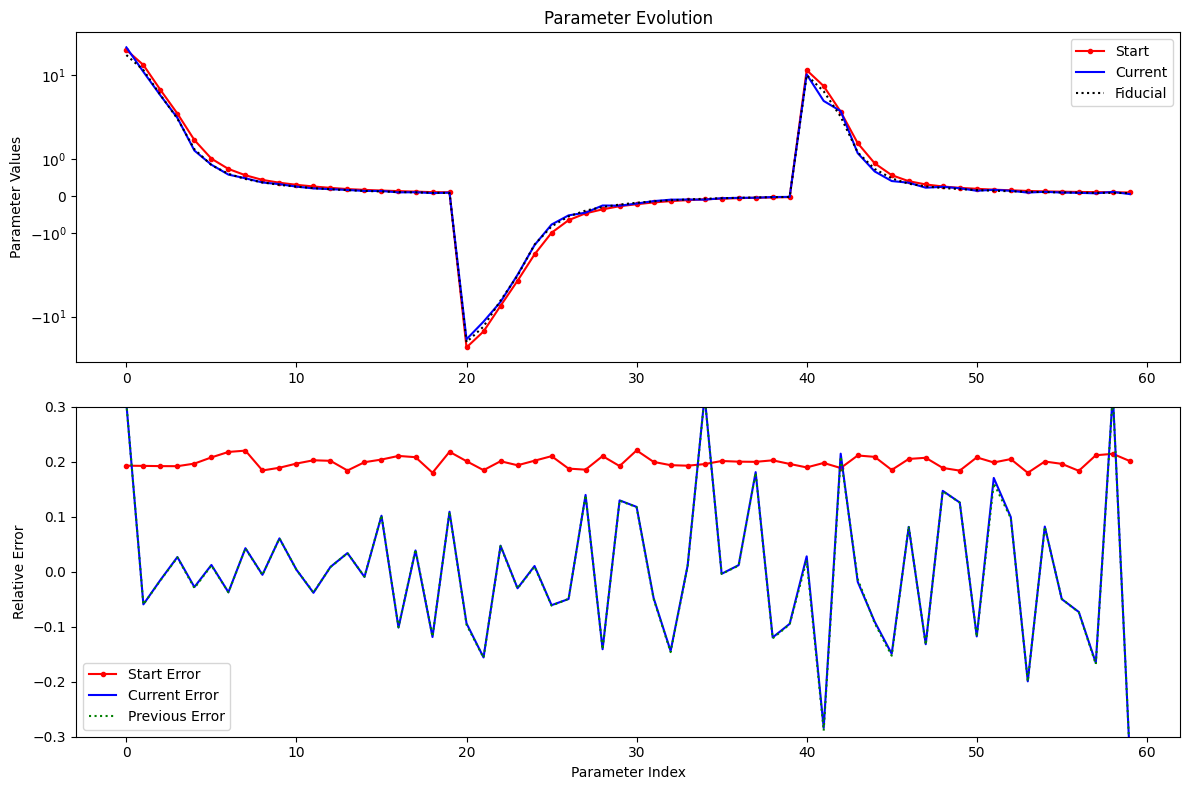

Optimization step: 139, learning rate: 0.066128
Optimization step: 140, learning rate: 0.066128
Optimization step: 141, learning rate: 0.066128
Optimization step: 142, learning rate: 0.062821
Optimization step: 143, learning rate: 0.062821
Optimization step: 144, learning rate: 0.062821


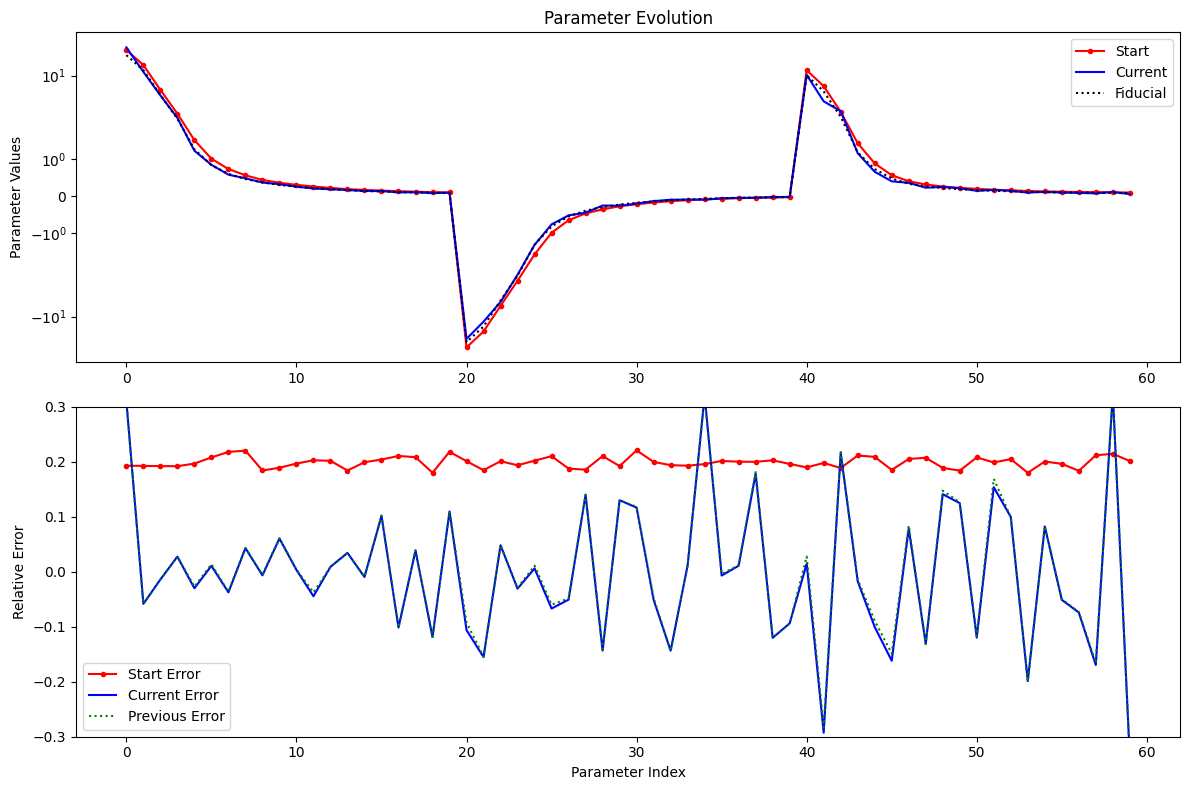

Optimization step: 145, learning rate: 0.059680
Optimization step: 146, learning rate: 0.059680
Optimization step: 147, learning rate: 0.059680
Optimization step: 148, learning rate: 0.056696
Optimization step: 149, learning rate: 0.056696
Optimization step: 150, learning rate: 0.056696


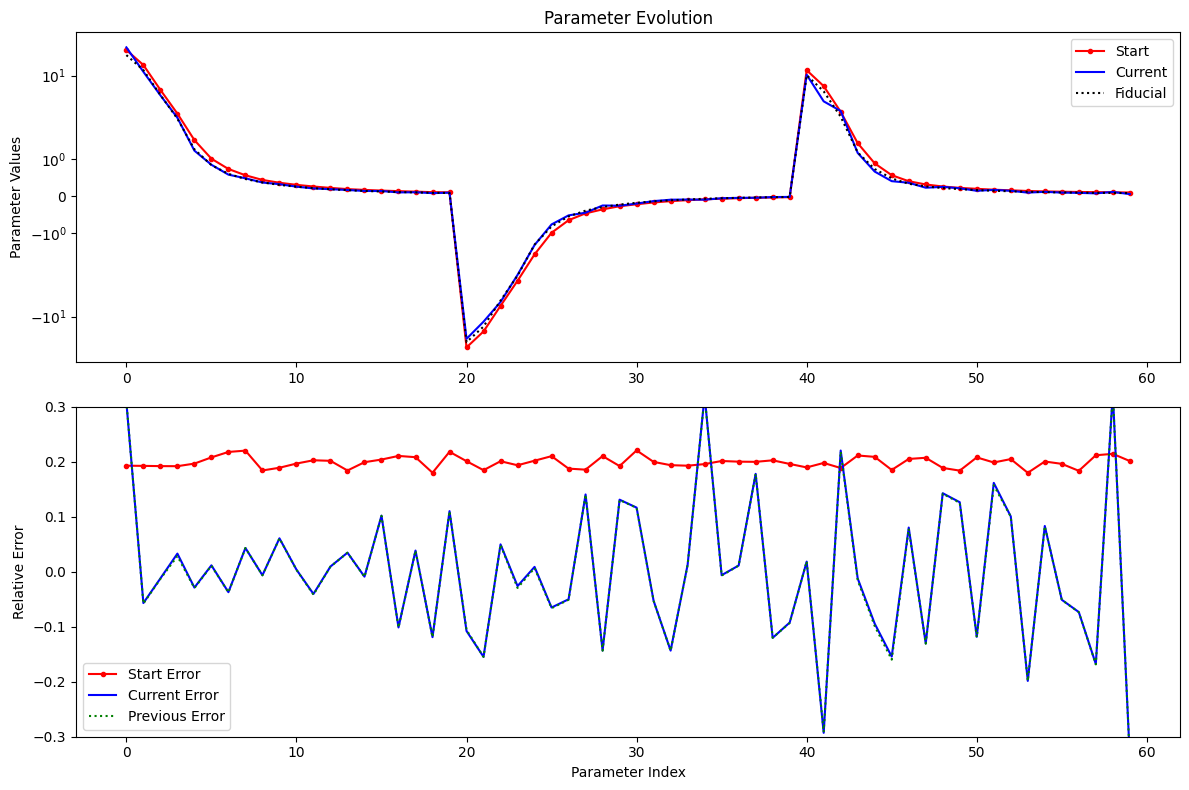

Optimization step: 151, learning rate: 0.475000
Optimization step: 152, learning rate: 0.475000
Optimization step: 153, learning rate: 0.475000
Optimization step: 154, learning rate: 0.451250
Optimization step: 155, learning rate: 0.451250
Optimization step: 156, learning rate: 0.451250


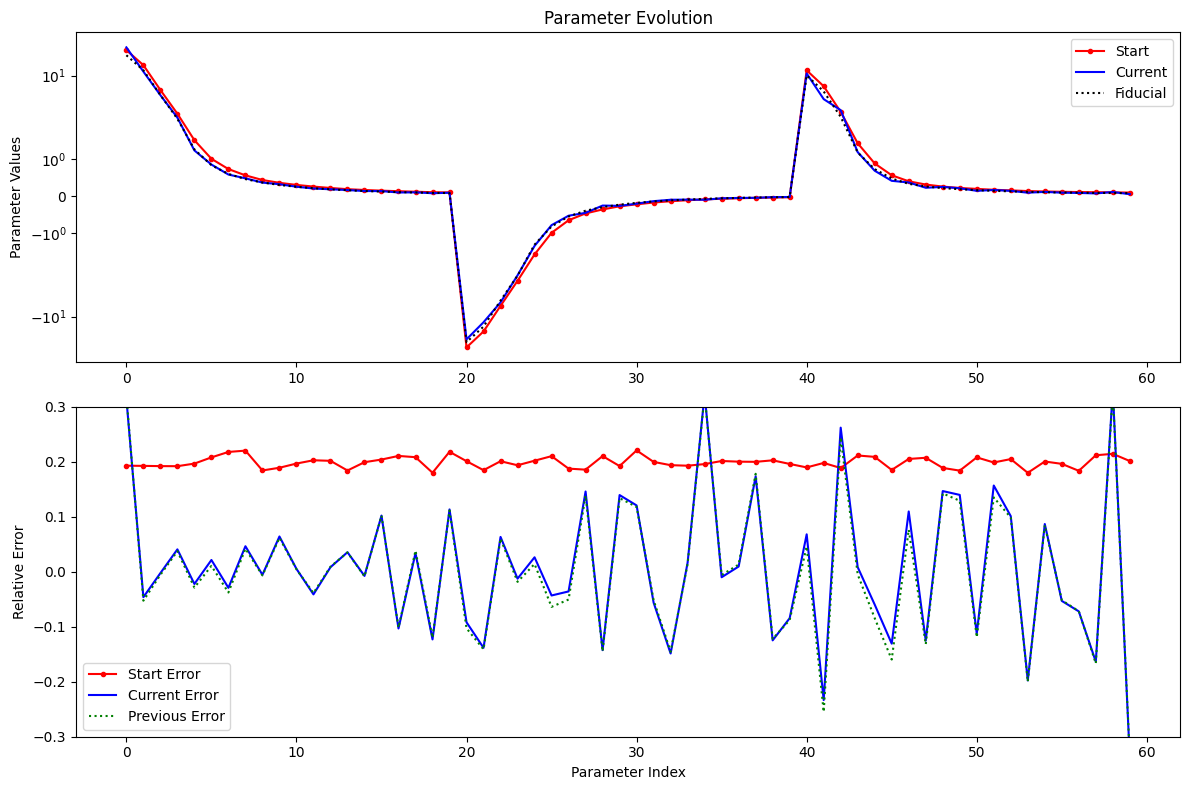

Optimization step: 157, learning rate: 0.428687
Optimization step: 158, learning rate: 0.428687
Optimization step: 159, learning rate: 0.428687
Optimization step: 160, learning rate: 0.407253
Optimization step: 161, learning rate: 0.407253
Optimization step: 162, learning rate: 0.407253


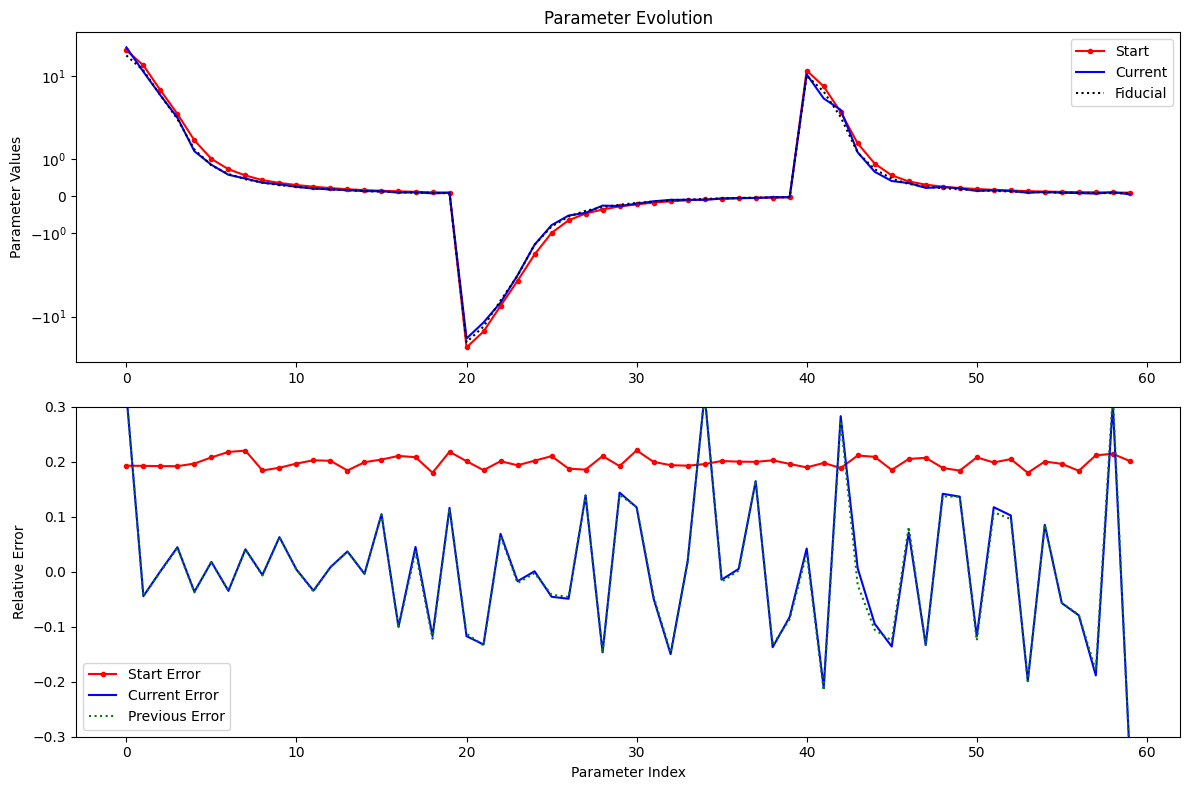

Optimization step: 163, learning rate: 0.386890
Optimization step: 164, learning rate: 0.386890
Optimization step: 165, learning rate: 0.386890
Optimization step: 166, learning rate: 0.367546
Optimization step: 167, learning rate: 0.367546
Optimization step: 168, learning rate: 0.367546


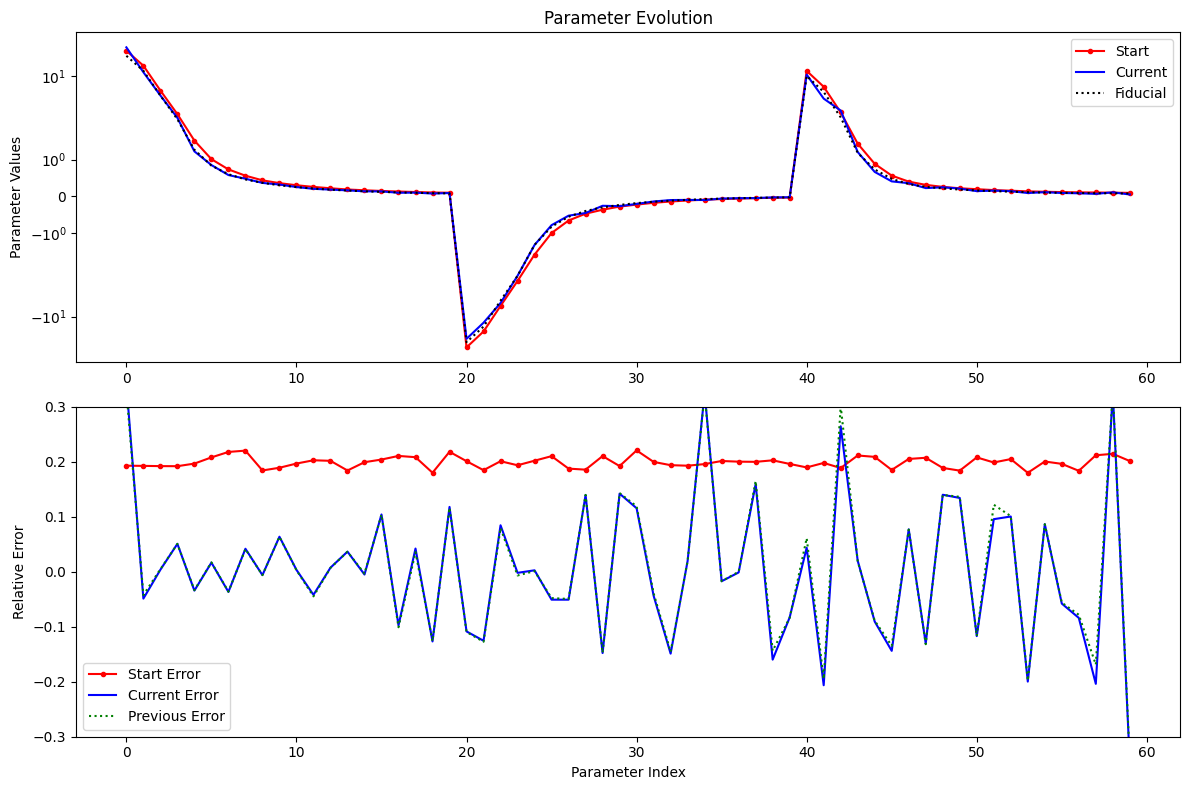

Optimization step: 169, learning rate: 0.349169
Optimization step: 170, learning rate: 0.349169
Optimization step: 171, learning rate: 0.349169
Optimization step: 172, learning rate: 0.331710
Optimization step: 173, learning rate: 0.331710
Optimization step: 174, learning rate: 0.331710


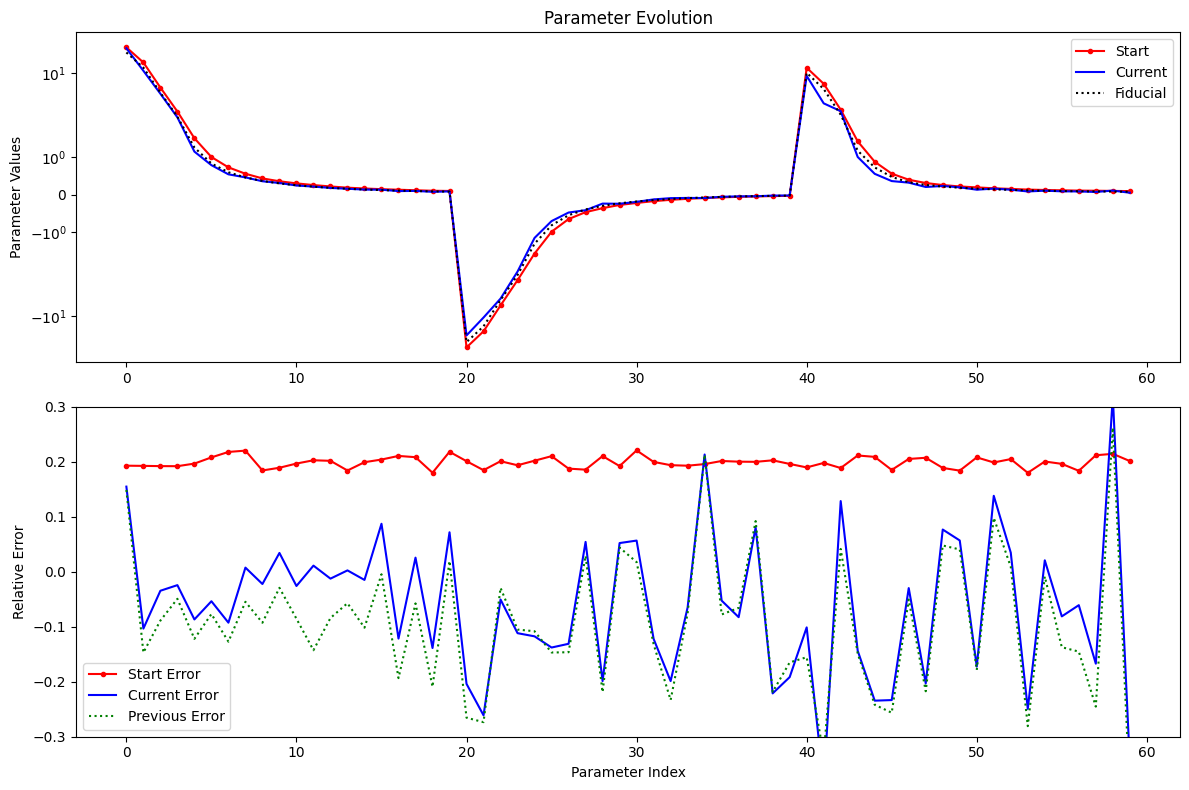

Optimization step: 175, learning rate: 0.315125
Optimization step: 176, learning rate: 0.315125
Optimization step: 177, learning rate: 0.315125
Optimization step: 178, learning rate: 0.299368
Optimization step: 179, learning rate: 0.299368
Optimization step: 180, learning rate: 0.299368


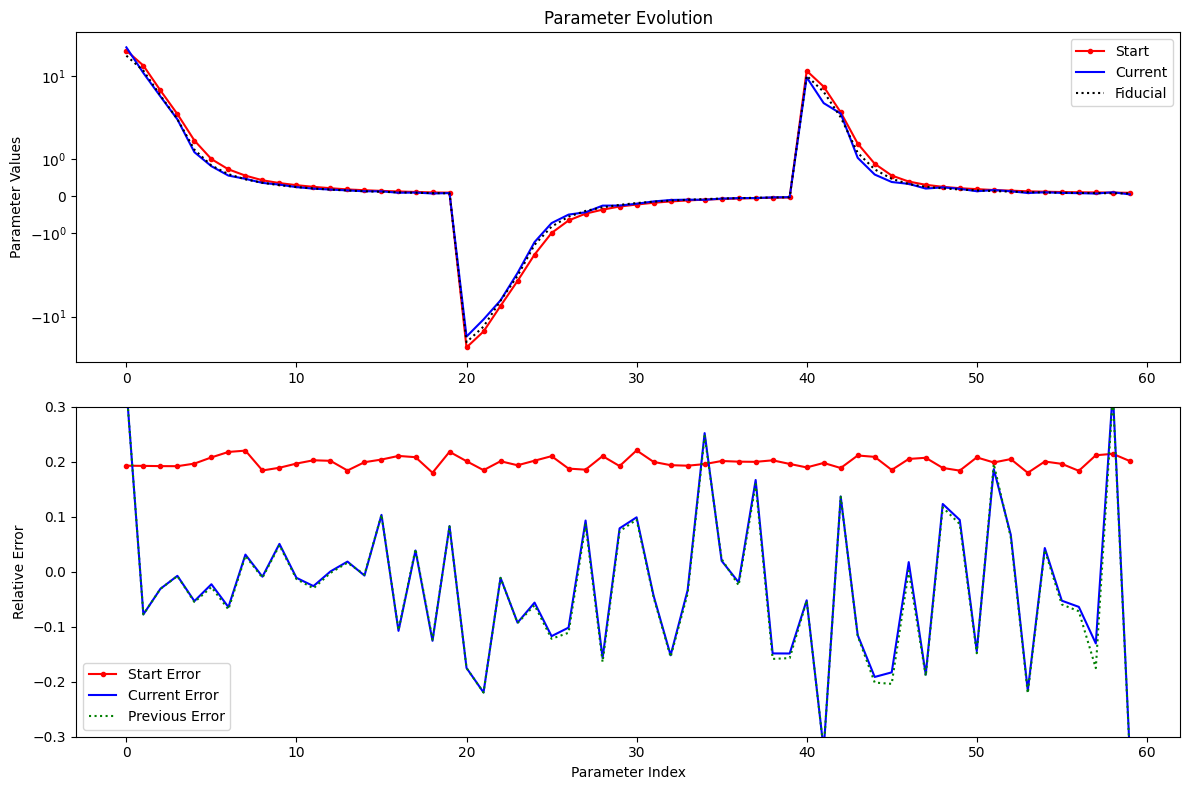

Optimization step: 181, learning rate: 0.284400
Optimization step: 182, learning rate: 0.284400
Optimization step: 183, learning rate: 0.284400
Optimization step: 184, learning rate: 0.270180
Optimization step: 185, learning rate: 0.270180
Optimization step: 186, learning rate: 0.270180


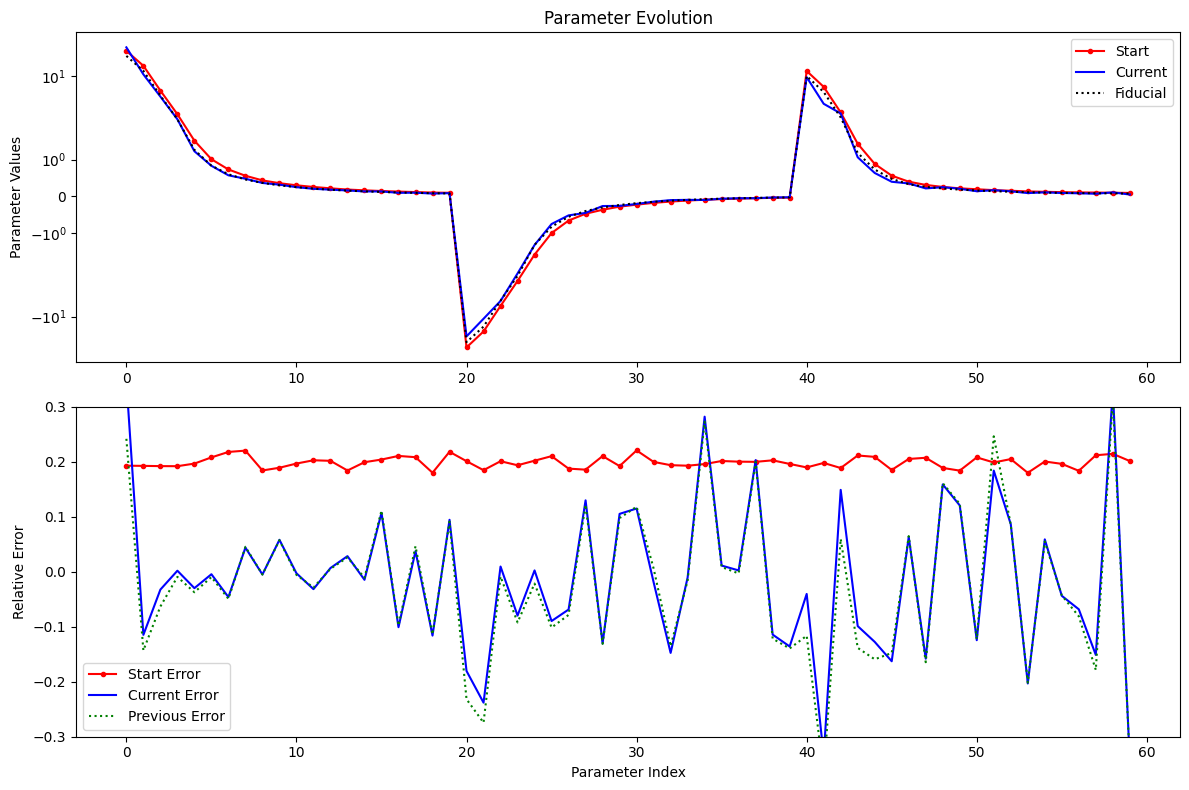

Optimization step: 187, learning rate: 0.256671
Optimization step: 188, learning rate: 0.256671
Optimization step: 189, learning rate: 0.256671
Optimization step: 190, learning rate: 0.243837
Optimization step: 191, learning rate: 0.243837
Optimization step: 192, learning rate: 0.243837


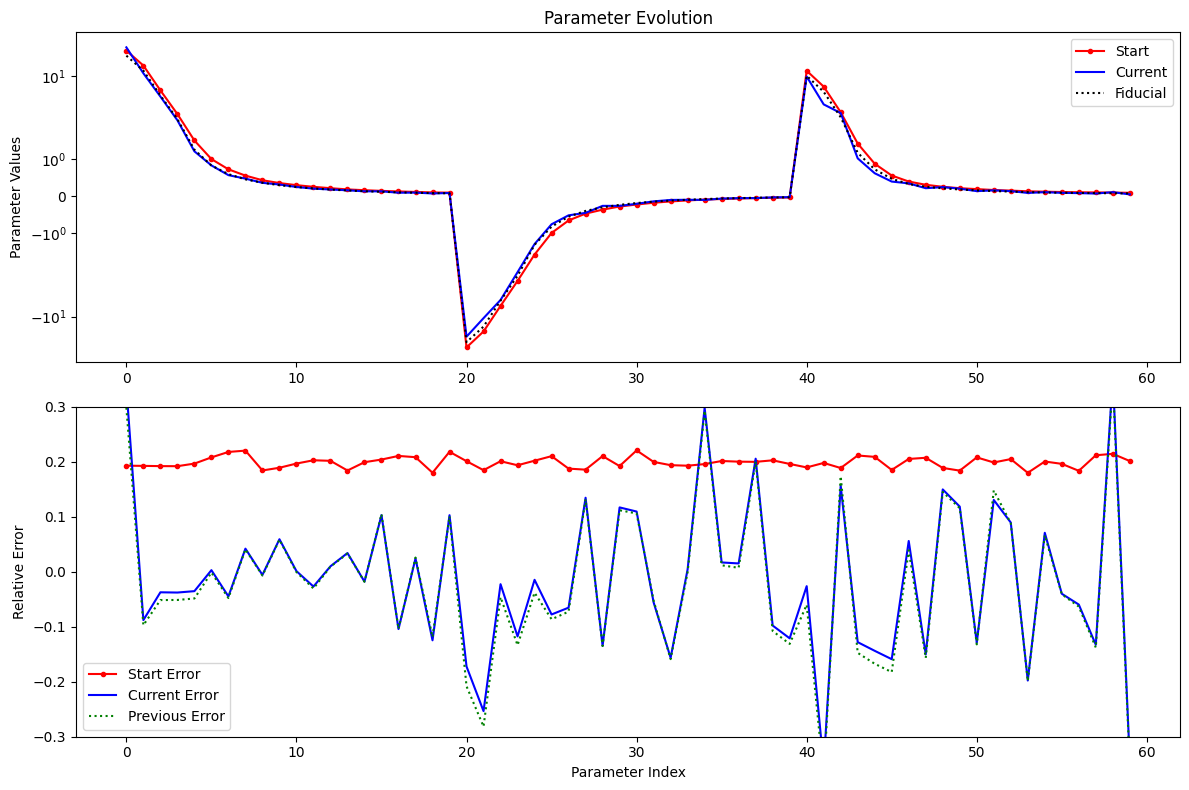

Optimization step: 193, learning rate: 0.231646
Optimization step: 194, learning rate: 0.231646
Optimization step: 195, learning rate: 0.231646
Optimization step: 196, learning rate: 0.220063
Optimization step: 197, learning rate: 0.220063
Optimization step: 198, learning rate: 0.220063


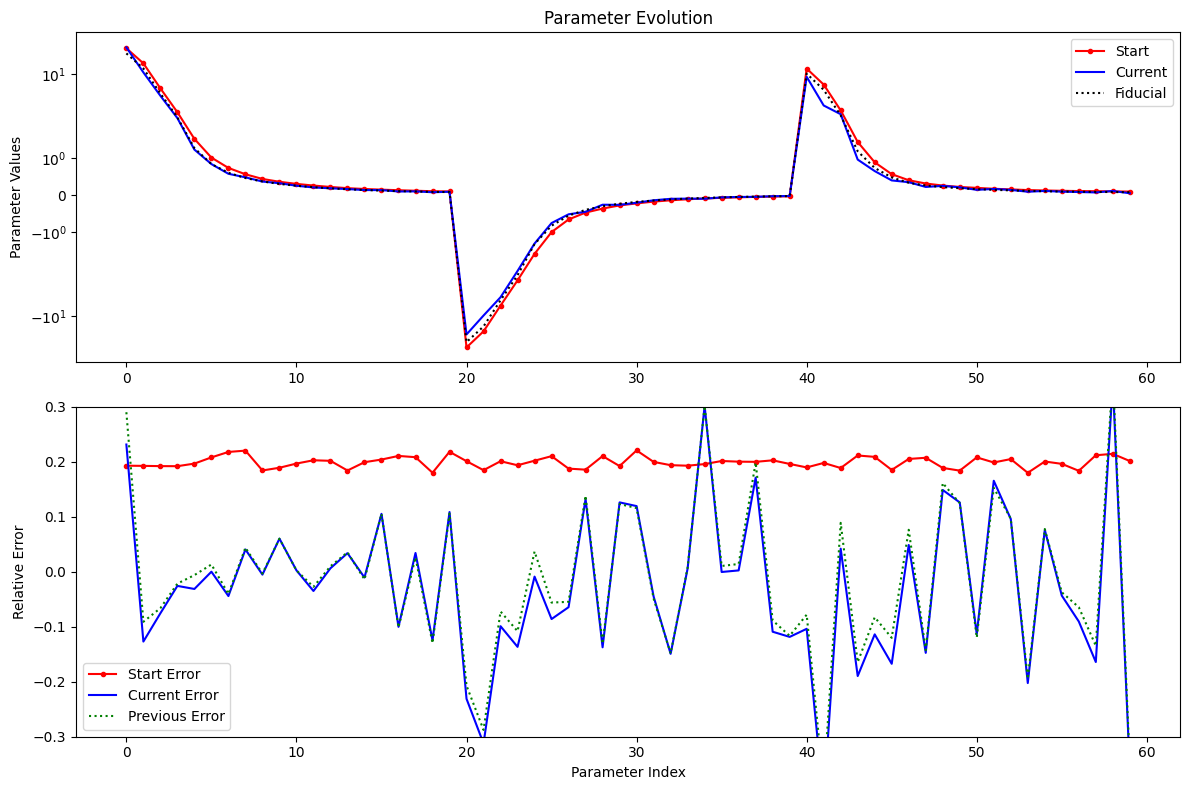

Optimization step: 199, learning rate: 0.209060
Optimization step: 200, learning rate: 0.209060


In [9]:
# Run optimization
print("Running MUSE optimization...")
optimizer = MuseOptimizer(problem, config)
opt_results = optimizer.run_optimization(x_data, start_point, rng)


In [10]:
θ_final = opt_results['θ_final']
s_MAP_sims = opt_results['s_MAP_sims']
z_MAP_sims = [z for z in opt_results['ẑs'] if z is not None]

estimator = CovarianceEstimator(problem, config)

# Compute score covariance
rng, subkey = jax.random.split(rng)
J = estimator.get_score_covariance(
    θ=θ_final,
    s_MAP_sims=s_MAP_sims,
    rng=subkey,
    nsims=config.get('***', {}).get('fisher_nsims', 20)
)

# Compute Fisher matrix
rng, subkey = jax.random.split(rng)
H = estimator.get_fisher_matrix(
    θ=θ_final,
    z_MAP_sims=z_MAP_sims,
    rng=subkey,
    nsims=config.get('***', {}).get('fisher_nsims', 20)
)

# Final covariance
cov_results = estimator.compute_covariance(θ_final, J, H)


Computing score covariance with 20 additional simulations...
Generating MAP scores...
Completed 20/20 score computations
Successfully generated 20 out of 20 scores
Score covariance computed from 30 simulations
Stacked scores shape: (30, 60)
Removed NaN entries, using 27 valid simulations
Score covariance condition number: 2.69e+23
Added regularization: 1.59e-02
Computing Fisher information matrix with 20 simulations...
Computing Hessian contributions...
Completed 5/20 Hessian computations
Completed 10/20 Hessian computations
Completed 15/20 Hessian computations
Completed 20/20 Hessian computations
Hessian array shape: (17, 60, 60)
Fisher matrix computed from 17 valid simulations
Fisher matrix condition number: 3.92e+04
Computing final parameter covariance...
Parameter dimension: 60
Score covariance shape: (60, 60)
Fisher matrix shape: (60, 60)
Covariance computation successful!
Parameter standard deviations: [0.14010849 0.17187754 0.11883426 0.08839678 0.06882298 0.05013782
 0.03022459

In [11]:
H_prior = cov_results["prior_hessian"]
Σ_inv = cov_results["precision"]
Σ = cov_results["covariance"]


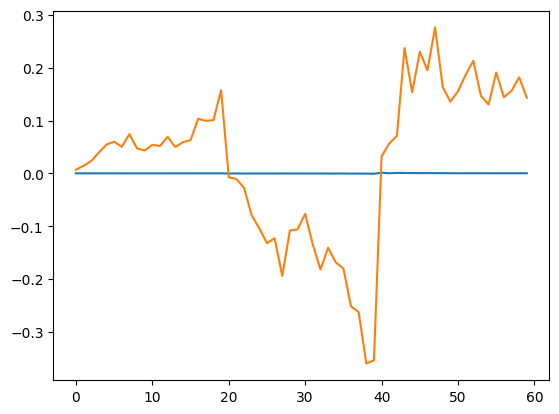

In [14]:
import matplotlib.pyplot as plt
plt.plot(1/np.sqrt(np.diag(Σ_inv))/problem.tf_cut_flat)
plt.plot(np.sqrt(np.diag(Σ))/problem.tf_cut_flat)

# plt.plot(abs((start_point-θ)/problem.tf_cut_flat),"k:")

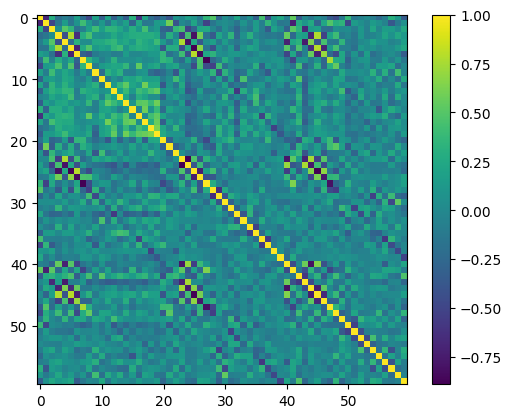

In [17]:
# covariance matrix
Σ_iijj = np.zeros(Σ_inv.shape)
for i in range(Σ_inv.shape[0]):
    for j in range(Σ_inv.shape[1]):
       Σ_iijj[i,j] = np.sqrt(Σ[i,i]*Σ[j,j])
plt.imshow(Σ/Σ_iijj)
plt.colorbar()

In [ ]:
def save_results(results, config):
    """Save analysis results"""
    output_dir = config.get('output_dir', './results')
    os.makedirs(output_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save parameter estimates

        
    # Save history

    print(f"Results saved to {output_dir}")


In [ ]:
save_results(results, config)
